E-Commerce Product Analysis - November 2019 Dataset
Powered by DuckDB — no chunking, low RAM, full 9 GB dataset

In [8]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
import matplotlib.patches as mpatches
 
warnings.filterwarnings("ignore")

CONFIGURATION

In [9]:
FILE_PATH  = r"C:\Users\nikes\Downloads\2019-Nov.csv\2019-Nov.csv"
OUTPUT_DIR = "product_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [10]:
con = duckdb.connect()
 
def q(sql):
    """Run SQL, return a pandas DataFrame."""
    return con.execute(sql).df()
 
# Reusable category expression (replaces the lambda in old code)
CAT_EXPR = "COALESCE(NULLIF(split_part(category_code, '.', 1), ''), 'unknown_category')"
BRAND_EXPR = "COALESCE(NULLIF(brand, ''), 'unknown_brand')"
 
print("=" * 60)
print("  DuckDB E-Commerce Analysis – November 2019")
print("=" * 60)
print(f"  Reading from : {FILE_PATH}")
print(f"  Outputs to   : ./{OUTPUT_DIR}/\n")

  DuckDB E-Commerce Analysis – November 2019
  Reading from : C:\Users\nikes\Downloads\2019-Nov.csv\2019-Nov.csv
  Outputs to   : ./product_analysis_output/



DATASET OVERVIEW

In [11]:
print("─" * 60)
print("DATASET OVERVIEW")
print("─" * 60)
 
overview = q(f"""
    SELECT
        COUNT(*)                                      AS total_rows,
        COUNT(DISTINCT product_id)                    AS unique_products,
        COUNT(DISTINCT user_id)                       AS unique_users,
        MIN(event_time::TIMESTAMP)                    AS earliest,
        MAX(event_time::TIMESTAMP)                    AS latest,
        COUNT(*) FILTER (WHERE category_code IS NULL) AS missing_category,
        COUNT(*) FILTER (WHERE brand IS NULL)         AS missing_brand
    FROM read_csv_auto('{FILE_PATH}')
""")
 
total_rows = int(overview["total_rows"][0])
print(overview.T.to_string(header=False))

────────────────────────────────────────────────────────────
DATASET OVERVIEW
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

total_rows                   67501979
unique_products                190662
unique_users                  3696117
earliest          2019-11-01 00:00:00
latest            2019-11-30 23:59:59
missing_category             21898171
missing_brand                 9218235


Missing Value analysis

In [12]:
print("MISSING VALUE ANALYSIS")
 
missing_cat  = int(overview["missing_category"][0])
missing_brand = int(overview["missing_brand"][0])
 
print(f"  category_code  : {missing_cat:>10,}  ({missing_cat/total_rows*100:.1f}%)")
print(f"  brand          : {missing_brand:>10,}  ({missing_brand/total_rows*100:.1f}%)")
print("  ✔ Handled in queries via COALESCE → 'unknown_category' / 'unknown_brand'")

MISSING VALUE ANALYSIS
  category_code  : 21,898,171  (32.4%)
  brand          :  9,218,235  (13.7%)
  ✔ Handled in queries via COALESCE → 'unknown_category' / 'unknown_brand'


EVENT TYPE DISTRIBUTION

EVENT TYPE DISTRIBUTION
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type
view        63556110
cart         3028930
purchase      916939


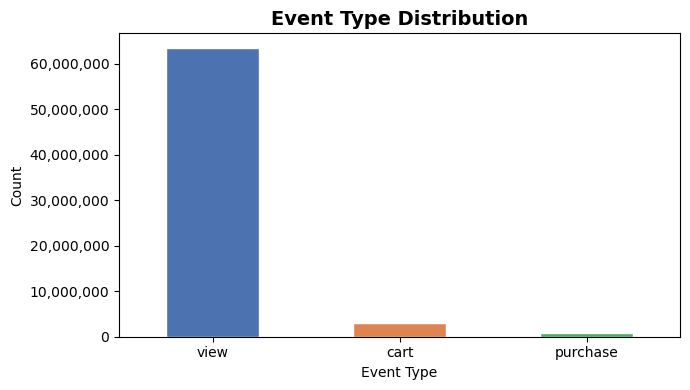

In [13]:
print("EVENT TYPE DISTRIBUTION")
print("─" * 60)
 
event_df = q(f"""
    SELECT event_type, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY event_type
    ORDER BY count DESC
""")
event_counts = event_df.set_index("event_type")["count"]
print(event_counts.to_string())
 
fig, ax = plt.subplots(figsize=(7, 4))
event_counts.plot(kind="bar", ax=ax,
                  color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                  edgecolor="white")
ax.set_title("Event Type Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Event Type"); ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=0); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/01_event_type_distribution.png", dpi=150)
plt.show(); 
plt.close()

CONVERSION FUNNEL

CONVERSION FUNNEL
────────────────────────────────────────────────────────────
  Views         :   63,556,110
  Carts         :    3,028,930  (4.77% of views)
  Purchases     :      916,939  (30.27% of carts)
  Overall Conv. :                  1.44% (view→purchase)


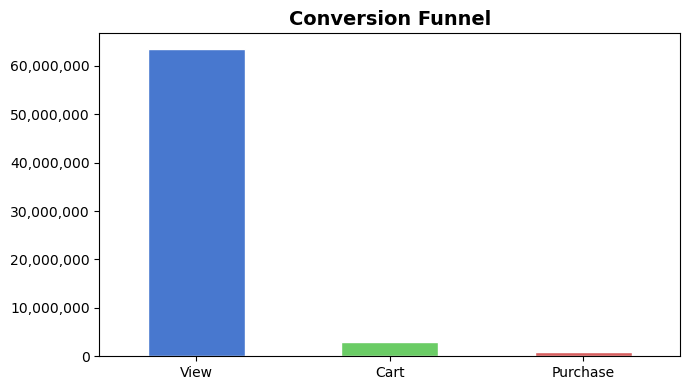

In [14]:
print("CONVERSION FUNNEL")
print("─" * 60)
 
views     = int(event_counts.get("view", 0))
carts     = int(event_counts.get("cart", 0))
purchases = int(event_counts.get("purchase", 0))
 
view_to_cart     = carts     / views     * 100 if views else 0
cart_to_purchase = purchases / carts     * 100 if carts else 0
view_to_purchase = purchases / views     * 100 if views else 0
 
print(f"  Views         : {views:>12,}")
print(f"  Carts         : {carts:>12,}  ({view_to_cart:.2f}% of views)")
print(f"  Purchases     : {purchases:>12,}  ({cart_to_purchase:.2f}% of carts)")
print(f"  Overall Conv. :                  {view_to_purchase:.2f}% (view→purchase)")
 
funnel_data = pd.Series({"View": views, "Cart": carts, "Purchase": purchases})
fig, ax = plt.subplots(figsize=(7, 4))
funnel_data.plot(kind="bar", ax=ax,
                 color=["#4878CF","#6ACC65","#D65F5F"], edgecolor="white")
ax.set_title("Conversion Funnel", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=0); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/02_conversion_funnel.png", dpi=150)
plt.show(); 
plt.close()

Top Categories


────────────────────────────────────────────────────────────
TOP CATEGORIES
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top 10 by Views:
main_category
electronics         21988192
unknown_category    20837460
appliances           8037980
computers            4029049
apparel              2942622
furniture            2058798
auto                 1164278
construction         1047072
kids                  779517
accessories           380373

Top 10 by Purchases:
main_category
electronics         493639
unknown_category    234218
appliances           99026
computers            34477
apparel              14215
furniture            11542
auto                 10719
construction          8699
kids                  6166
accessories           2154


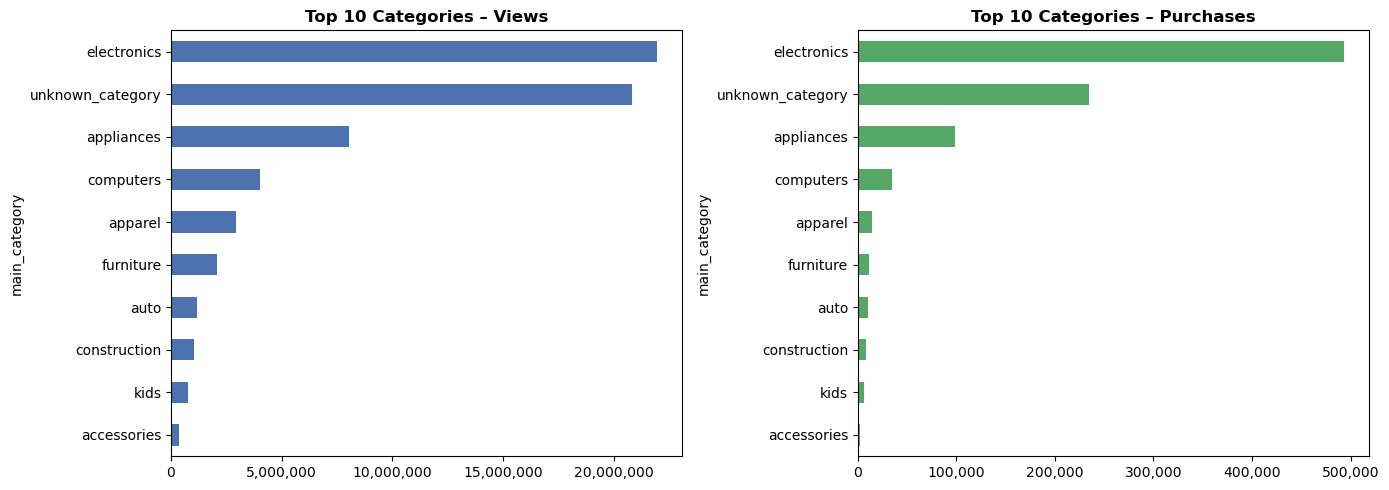

In [15]:
print("\n" + "─" * 60)
print("TOP CATEGORIES")
print("─" * 60)
 
cat_views = q(f"""
    SELECT {CAT_EXPR} AS main_category, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'view'
    GROUP BY 1 ORDER BY count DESC LIMIT 10
""").set_index("main_category")["count"]
 
cat_purchases = q(f"""
    SELECT {CAT_EXPR} AS main_category, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY 1 ORDER BY count DESC LIMIT 10
""").set_index("main_category")["count"]
 
print("\nTop 10 by Views:");    print(cat_views.to_string())
print("\nTop 10 by Purchases:"); print(cat_purchases.to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_views.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Categories – Views", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
cat_purchases.sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 Categories – Purchases", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/03_top_categories.png", dpi=150)
plt.show(); 
plt.close()

Top Brands


────────────────────────────────────────────────────────────
TOP BRANDS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top 15 Brands by Purchases:
brand
samsung     200027
apple       166064
xiaomi       68292
huawei       23703
cordiant     16983
oppo         15080
lucente      14559
lg           12879
sony         10309
artel         9267
bosch         8010
lenovo        6547
acer          6402
nokian        5981
viatti        5578


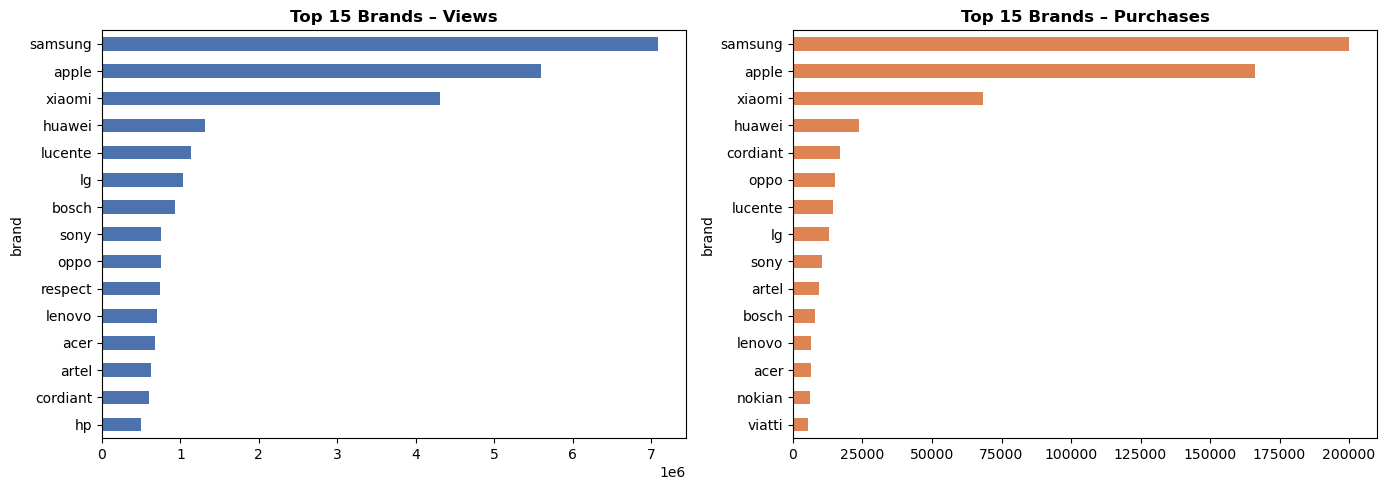

In [16]:
print("\n" + "─" * 60)
print("TOP BRANDS")
print("─" * 60)
 
brand_views = q(f"""
    SELECT {BRAND_EXPR} AS brand, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'view' AND brand IS NOT NULL
    GROUP BY 1 ORDER BY count DESC LIMIT 15
""").set_index("brand")["count"]
 
brand_purchases = q(f"""
    SELECT {BRAND_EXPR} AS brand, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND brand IS NOT NULL
    GROUP BY 1 ORDER BY count DESC LIMIT 15
""").set_index("brand")["count"]
 
print("\nTop 15 Brands by Purchases:"); print(brand_purchases.to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
brand_views.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 15 Brands – Views", fontweight="bold")
 
brand_purchases.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Top 15 Brands – Purchases", fontweight="bold")
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/04_top_brands.png", dpi=150)
plt.show(); plt.close()

As Above shown in the picture, you can see 'cordiant' have less views than many brands but is above in purchased section than many companies


--PRICE ANALYSIS--


────────────────────────────────────────────────────────────
PRICE ANALYSIS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type  min     max   mean    std  median
      cart 0.77 2574.07 290.40 335.00  168.70
  purchase 0.77 2574.07 300.12 341.38  169.96
      view 0.77 2574.07 293.31 357.00  166.03


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

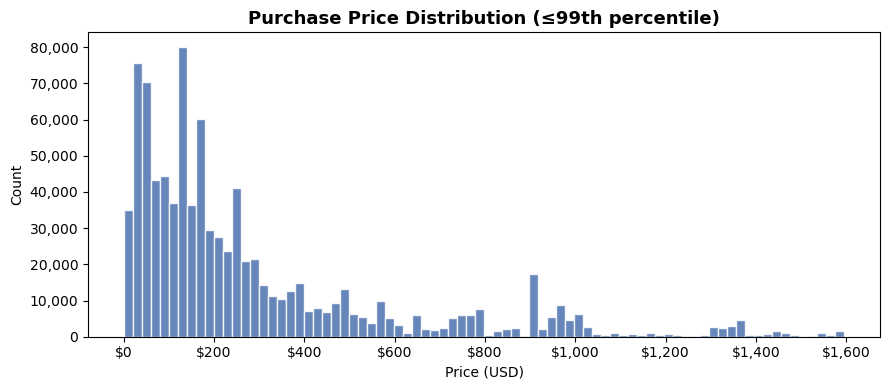

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

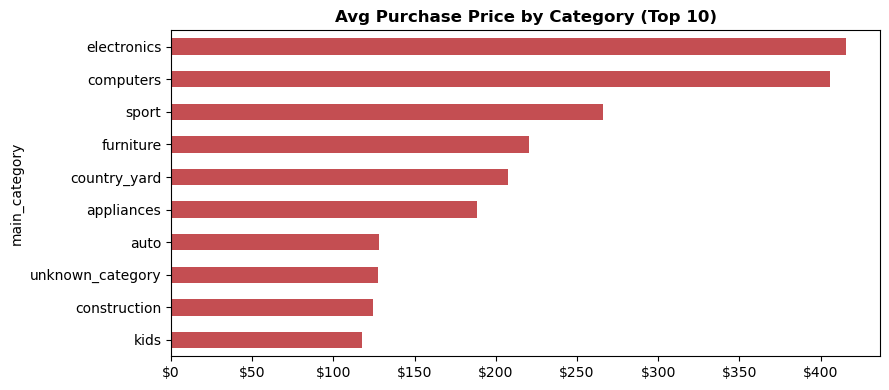

In [17]:
print("\n" + "─" * 60)
print("PRICE ANALYSIS")
print("─" * 60)
 
price_stats = q(f"""
    SELECT event_type,
           ROUND(MIN(price),2)    AS min,
           ROUND(MAX(price),2)    AS max,
           ROUND(AVG(price),2)    AS mean,
           ROUND(STDDEV(price),2) AS std,
           ROUND(MEDIAN(price),2) AS median
    FROM read_csv_auto('{FILE_PATH}')
    WHERE price > 0
    GROUP BY event_type ORDER BY event_type
""")
print(price_stats.to_string(index=False))
 
# Price distribution – fetch purchase prices as a small sample for histogram
p99 = float(q(f"""
    SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY price) AS p99
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0
""")["p99"][0])
 
purchase_prices = q(f"""
    SELECT price FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0 AND price <= {p99}
""")["price"]
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(purchase_prices, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("Purchase Price Distribution (≤99th percentile)", fontsize=13, fontweight="bold")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/05_purchase_price_dist.png", dpi=150)
plt.show(); plt.close()
 
avg_price_cat = q(f"""
    SELECT {CAT_EXPR} AS main_category, ROUND(AVG(price),2) AS avg_price
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0
    GROUP BY 1 ORDER BY avg_price DESC LIMIT 10
""").set_index("main_category")["avg_price"]
 
fig, ax = plt.subplots(figsize=(9, 4))
avg_price_cat.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Avg Purchase Price by Category (Top 10)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/06_avg_price_by_category.png", dpi=150)
plt.show(); plt.close()

Top Product


────────────────────────────────────────────────────────────
TOP PRODUCTS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top 10 Viewed Products:
 product_id   brand main_category  avg_price  count
    1005115   apple   electronics     923.40 583010
    1004856 samsung   electronics     127.30 522880
    1004767 samsung   electronics     245.57 482898
    4804056   apple   electronics     162.71 318339
    1005160  xiaomi   electronics     202.42 304614
    1005105   apple   electronics    1351.34 275721
    1004870 samsung   electronics     281.99 272097
    1004249   apple   electronics     758.31 254931
    1004833 samsung   electronics     170.63 247446
    1002544   apple   electronics     475.65 229920

Top 10 Purchased Products:
 product_id   brand main_category  avg_price  count
    1004856 samsung   electronics     127.44  32321
    1004767 samsung   electronics     246.50  22613
    1005115   apple   electronics     927.24  22244
    4804056   apple   electronics     164.70  17800
    1004833 samsung   electronics     171.33  13486
    1002544   apple   electronics     479.81  11678
    1004870

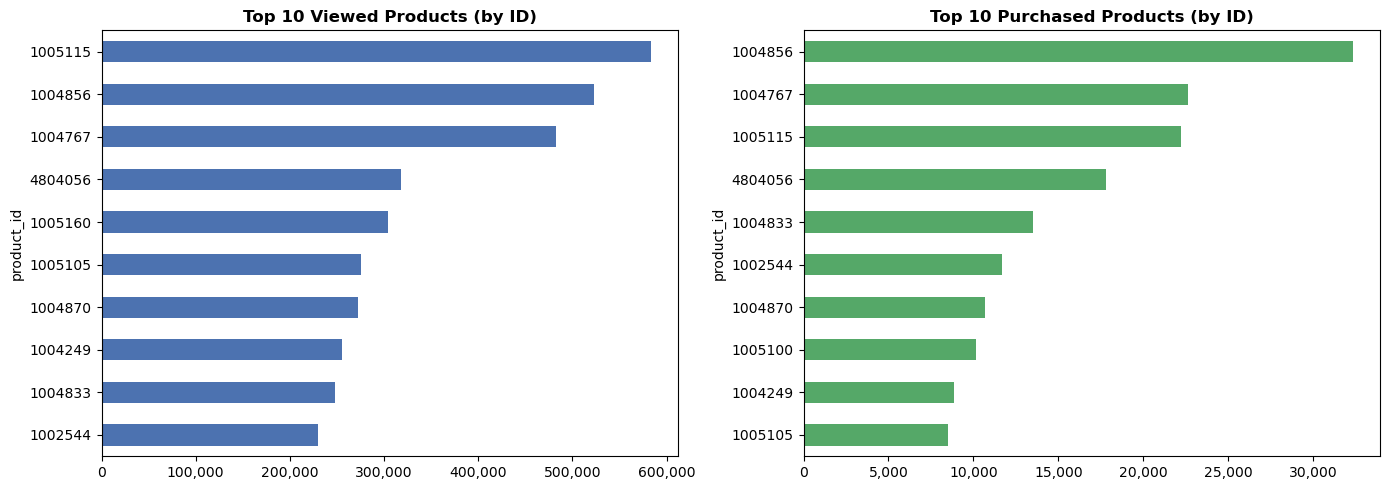

In [18]:
print("\n" + "─" * 60)
print("TOP PRODUCTS")
print("─" * 60)
 
top_viewed_df = q(f"""
    SELECT product_id,
           MAX({BRAND_EXPR})    AS brand,
           MAX({CAT_EXPR})      AS main_category,
           ROUND(AVG(price),2)  AS avg_price,
           COUNT(*)             AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'view'
    GROUP BY product_id ORDER BY count DESC LIMIT 10
""")
 
top_purchased_df = q(f"""
    SELECT product_id,
           MAX({BRAND_EXPR})    AS brand,
           MAX({CAT_EXPR})      AS main_category,
           ROUND(AVG(price),2)  AS avg_price,
           COUNT(*)             AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY product_id ORDER BY count DESC LIMIT 10
""")
 
print("\nTop 10 Viewed Products:");    print(top_viewed_df.to_string(index=False))
print("\nTop 10 Purchased Products:"); print(top_purchased_df.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_viewed_df.set_index("product_id")["count"].sort_values().plot(
    kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Viewed Products (by ID)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
top_purchased_df.set_index("product_id")["count"].sort_values().plot(
    kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 Purchased Products (by ID)", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/07_top_products.png", dpi=150)
plt.show(); plt.close()

Revenue Analysis


────────────────────────────────────────────────────────────
REVENUE ANALYSIS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Total Revenue   : $ 275,194,890.50
  Total Orders    :         916,939
  Avg Order Value : $         300.12


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

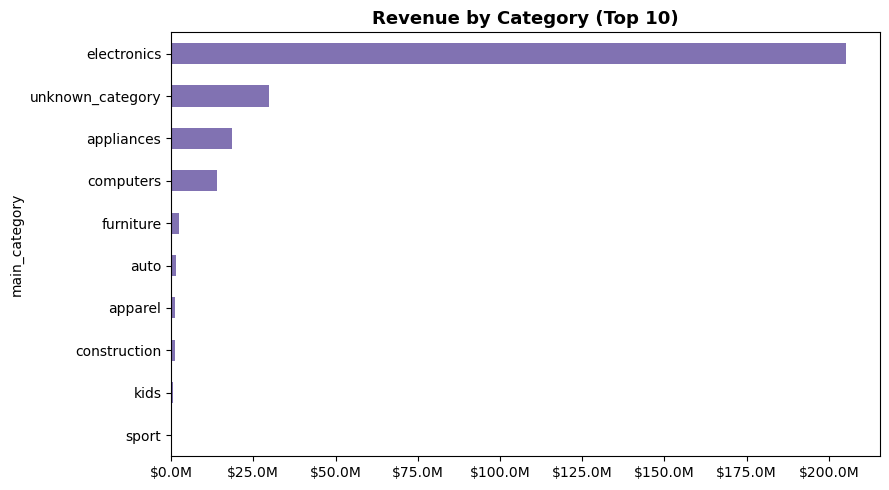

In [19]:
print("\n" + "─" * 60)
print("REVENUE ANALYSIS")
print("─" * 60)
 
rev_summary = q(f"""
    SELECT
        ROUND(SUM(price),2)  AS total_revenue,
        COUNT(*)             AS total_orders,
        ROUND(AVG(price),2)  AS avg_order_value
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
""")
total_revenue   = float(rev_summary["total_revenue"][0])
total_orders    = int(rev_summary["total_orders"][0])
avg_order_value = float(rev_summary["avg_order_value"][0])
 
print(f"  Total Revenue   : ${total_revenue:>15,.2f}")
print(f"  Total Orders    : {total_orders:>15,}")
print(f"  Avg Order Value : ${avg_order_value:>15,.2f}")
 
rev_by_cat = q(f"""
    SELECT {CAT_EXPR} AS main_category, ROUND(SUM(price),2) AS revenue
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY 1 ORDER BY revenue DESC LIMIT 10
""").set_index("main_category")["revenue"]
 
fig, ax = plt.subplots(figsize=(9, 5))
rev_by_cat.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Revenue by Category (Top 10)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/08_revenue_by_category.png", dpi=150)
plt.show(); plt.close()

Daily Trends


────────────────────────────────────────────────────────────
DAILY TRENDS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

               view   cart  purchase
date                                
2019-11-26  1559008  71645     24226
2019-11-27  1550616  71397     24443
2019-11-28  1562532  71541     24305
2019-11-29  1729925  92394     32107
2019-11-30  1644939  81761     28178


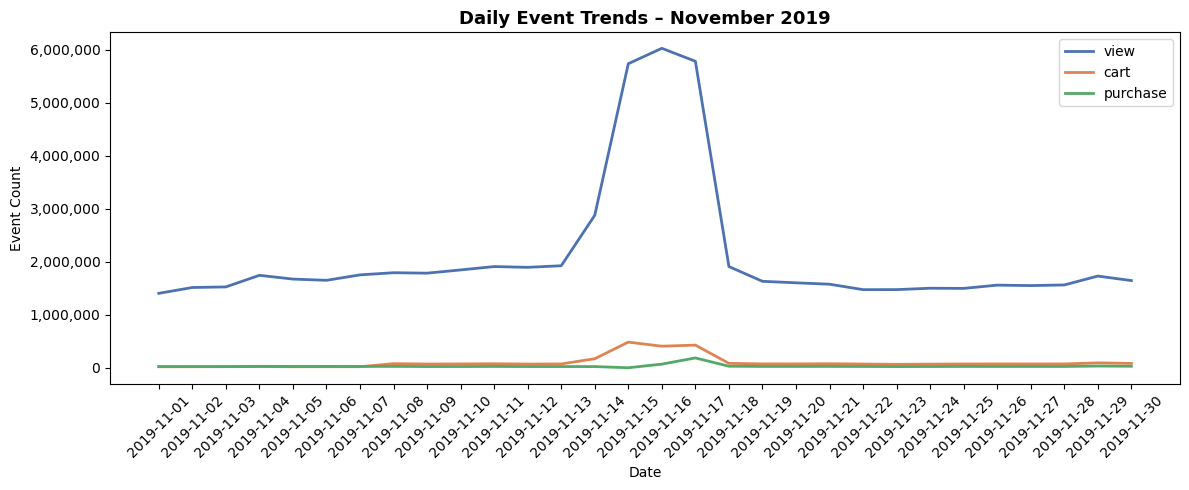

In [20]:
print("\n" + "─" * 60)
print("DAILY TRENDS")
print("─" * 60)
 
daily = q(f"""
    SELECT
        strftime(event_time::TIMESTAMP, '%Y-%m-%d') AS date,
        COUNT(*) FILTER (WHERE event_type='view')     AS view,
        COUNT(*) FILTER (WHERE event_type='cart')     AS cart,
        COUNT(*) FILTER (WHERE event_type='purchase') AS purchase
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY 1 ORDER BY 1
""").set_index("date")
 
print(daily.tail(5))
 
fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(daily.columns, ["#4C72B0","#DD8452","#55A868","#C44E52"]):
    ax.plot(daily.index, daily[col], label=col, color=color, linewidth=2)
ax.set_title("Daily Event Trends – November 2019", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Event Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/09_daily_trends.png", dpi=150)
plt.show(); 
plt.close()

Hourly purchase pattern


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

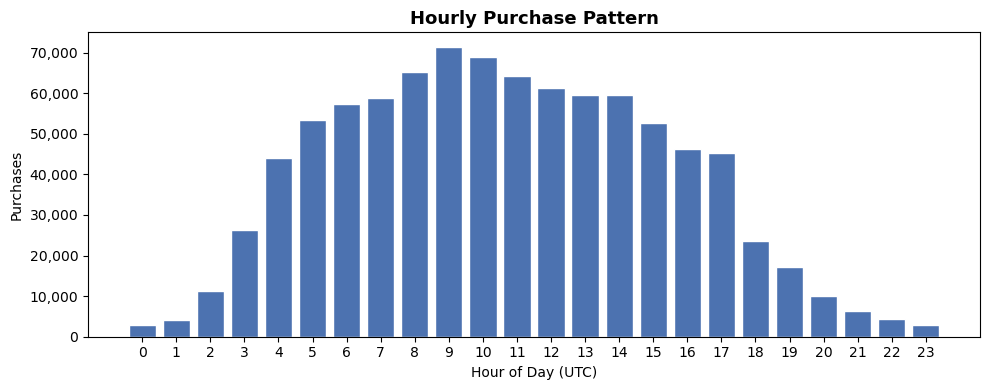

In [21]:
hourly_purchase = q(f"""
    SELECT EXTRACT(hour FROM event_time::TIMESTAMP)::INT AS hour,
           COUNT(*) AS purchases
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY 1 ORDER BY 1
""").set_index("hour")["purchases"]
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_purchase.index, hourly_purchase.values,
       color="#4C72B0", edgecolor="white")
ax.set_title("Hourly Purchase Pattern", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day (UTC)"); ax.set_ylabel("Purchases")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(24)); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/10_hourly_purchase_pattern.png", dpi=150)
plt.show(); 
plt.close()

CATEGORY CONVERSION RATES


────────────────────────────────────────────────────────────
CATEGORY CONVERSION RATES
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

main_category
electronics         2.25%
medicine            1.66%
stationery          1.60%
appliances          1.23%
unknown_category    1.12%
auto                0.92%
computers           0.86%
construction        0.83%
kids                0.79%
sport               0.62%
accessories         0.57%
furniture           0.56%
apparel             0.48%
country_yard        0.35%


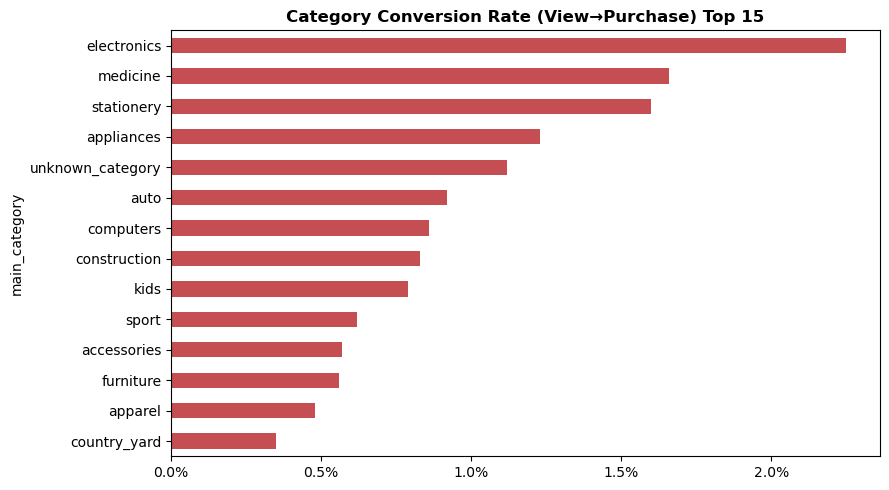

In [22]:
print("\n" + "─" * 60)
print("CATEGORY CONVERSION RATES")
print("─" * 60)
 
cat_conv = q(f"""
    SELECT
        {CAT_EXPR} AS main_category,
        COUNT(*) FILTER (WHERE event_type='view')     AS views,
        COUNT(*) FILTER (WHERE event_type='purchase') AS purchases,
        ROUND(100.0 *
            COUNT(*) FILTER (WHERE event_type='purchase') /
            NULLIF(COUNT(*) FILTER (WHERE event_type='view'), 0), 2) AS conv_rate
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY 1
    HAVING views >= 1000
    ORDER BY conv_rate DESC
    LIMIT 15
""").set_index("main_category")
 
print(cat_conv["conv_rate"].apply(lambda x: f"{x:.2f}%").to_string())
 
fig, ax = plt.subplots(figsize=(9, 5))
cat_conv["conv_rate"].sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Category Conversion Rate (View→Purchase) Top 15", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/11_category_conversion_rates.png", dpi=150)
plt.show(); plt.close()

Brand Conversion rate

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

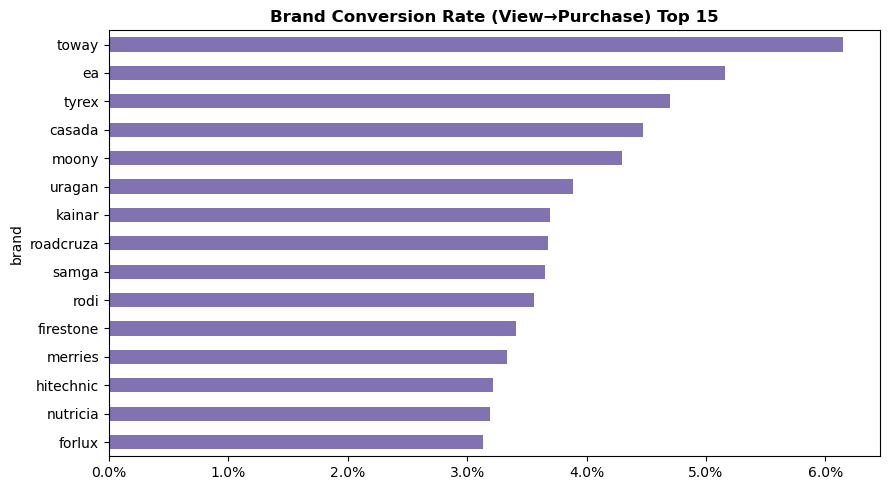

In [23]:
brand_conv = q(f"""
    SELECT
        {BRAND_EXPR} AS brand,
        COUNT(*) FILTER (WHERE event_type='view')     AS views,
        COUNT(*) FILTER (WHERE event_type='purchase') AS purchases,
        ROUND(100.0 *
            COUNT(*) FILTER (WHERE event_type='purchase') /
            NULLIF(COUNT(*) FILTER (WHERE event_type='view'), 0), 2) AS conv_rate
    FROM read_csv_auto('{FILE_PATH}')
    WHERE brand IS NOT NULL
    GROUP BY 1
    HAVING views >= 500
    ORDER BY conv_rate DESC
    LIMIT 15
""").set_index("brand")
 
fig, ax = plt.subplots(figsize=(9, 5))
brand_conv["conv_rate"].sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Brand Conversion Rate (View→Purchase) Top 15", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/12_brand_conversion_rates.png", dpi=150)
plt.show(); 
plt.close()

In [24]:
 # ─────────────────────────────────────────────
# S1.  SESSION METRICS
#      Avg session length, events per session,
#      conversion per session
# ─────────────────────────────────────────────
print("\n" + "─" * 60)
print("SESSION METRICS")
print("─" * 60)
 
session_metrics = q(f"""
    WITH session_stats AS (
        SELECT
            user_session,
            COUNT(*)                                          AS events_in_session,
            MIN(event_time::TIMESTAMP)                        AS session_start,
            MAX(event_time::TIMESTAMP)                        AS session_end,
            EPOCH(MAX(event_time::TIMESTAMP)
                - MIN(event_time::TIMESTAMP)) / 60.0          AS duration_mins,
            MAX(CASE WHEN event_type = 'purchase' THEN 1
                     ELSE 0 END)                              AS converted,
            MAX(CASE WHEN event_type = 'cart'     THEN 1
                     ELSE 0 END)                              AS carted,
            SUM(CASE WHEN event_type = 'purchase'
                     THEN price ELSE 0 END)                   AS session_revenue
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
    )
    SELECT
        COUNT(*)                              AS total_sessions,
        ROUND(AVG(events_in_session), 2)      AS avg_events_per_session,
        ROUND(AVG(duration_mins), 2)          AS avg_session_length_mins,
        ROUND(MEDIAN(duration_mins), 2)       AS median_session_length_mins,
        ROUND(AVG(converted) * 100, 2)        AS pct_sessions_converted,
        ROUND(AVG(carted) * 100, 2)           AS pct_sessions_carted,
        SUM(converted)                        AS converting_sessions,
        ROUND(AVG(CASE WHEN converted = 1
              THEN session_revenue END), 2)   AS avg_revenue_per_converting_session
    FROM session_stats
""")
 
print(session_metrics.T.to_string(header=False))


────────────────────────────────────────────────────────────
SESSION METRICS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

total_sessions                      13776051.00
avg_events_per_session                     4.90
avg_session_length_mins                   15.52
median_session_length_mins                 1.00
pct_sessions_converted                     5.61
pct_sessions_carted                       12.65
converting_sessions                   773214.00
avg_revenue_per_converting_session       355.91


Events per session distribution

In [25]:
events_dist = q(f"""
    WITH s AS (
        SELECT user_session, COUNT(*) AS events
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
    ),
    bucketed AS (
        SELECT
            CASE
                WHEN events = 1   THEN '1 event'
                WHEN events <= 3  THEN '2–3 events'
                WHEN events <= 5  THEN '4–5 events'
                WHEN events <= 10 THEN '6–10 events'
                WHEN events <= 20 THEN '11–20 events'
                ELSE '20+ events'
            END AS bucket,
            CASE
                WHEN events = 1   THEN 1
                WHEN events <= 3  THEN 2
                WHEN events <= 5  THEN 3
                WHEN events <= 10 THEN 4
                WHEN events <= 20 THEN 5
                ELSE 6
            END AS sort_order,
            1 AS cnt
        FROM s
    )
    SELECT bucket, SUM(cnt) AS sessions
    FROM bucketed
    GROUP BY bucket, sort_order
    ORDER BY sort_order
""")

print(events_dist.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      bucket  sessions
     1 event 5000967.0
  2–3 events 3605671.0
  4–5 events 1768806.0
 6–10 events 1861986.0
11–20 events 1044758.0
  20+ events  493863.0


Session length distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

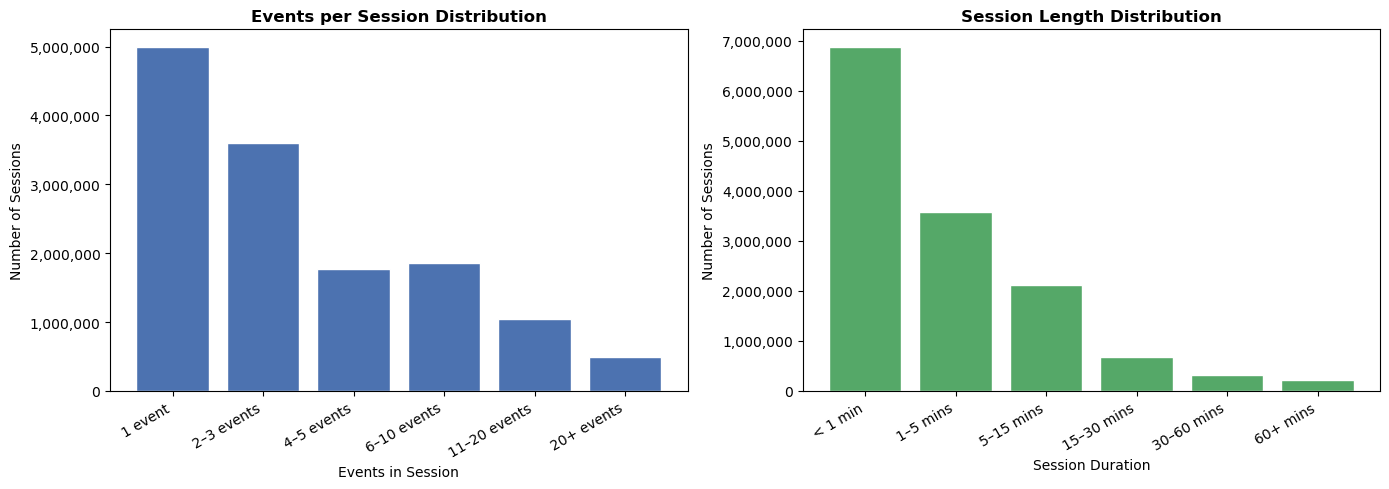

In [26]:
length_dist = q(f"""
    WITH s AS (
        SELECT user_session,
               EPOCH(MAX(event_time::TIMESTAMP)
                   - MIN(event_time::TIMESTAMP)) / 60.0 AS duration_mins
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
    )
    SELECT
        CASE
            WHEN duration_mins < 1   THEN '< 1 min'
            WHEN duration_mins < 5   THEN '1–5 mins'
            WHEN duration_mins < 15  THEN '5–15 mins'
            WHEN duration_mins < 30  THEN '15–30 mins'
            WHEN duration_mins < 60  THEN '30–60 mins'
            ELSE '60+ mins'
        END AS bucket,
        COUNT(*) AS sessions
    FROM s
    GROUP BY 1
    ORDER BY MIN(duration_mins)
""")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].bar(events_dist["bucket"], events_dist["sessions"],
            color="#4C72B0", edgecolor="white")
axes[0].set_title("Events per Session Distribution", fontweight="bold")
axes[0].set_xlabel("Events in Session")
axes[0].set_ylabel("Number of Sessions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")
 
axes[1].bar(length_dist["bucket"], length_dist["sessions"],
            color="#55A868", edgecolor="white")
axes[1].set_title("Session Length Distribution", fontweight="bold")
axes[1].set_xlabel("Session Duration")
axes[1].set_ylabel("Number of Sessions")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/13_session_distributions.png", dpi=150)
plt.show(); 
plt.close()

 SESSION DEPTH FUNNEL
 (How deep do users go within a session?)


────────────────────────────────────────────────────────────
SESSION DEPTH FUNNEL
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

viewed                13766768.00
carted                 1743343.00
purchased               773214.00
total_sessions        13776051.00
view_to_cart_pct            12.66
cart_to_purchase_pct        44.35


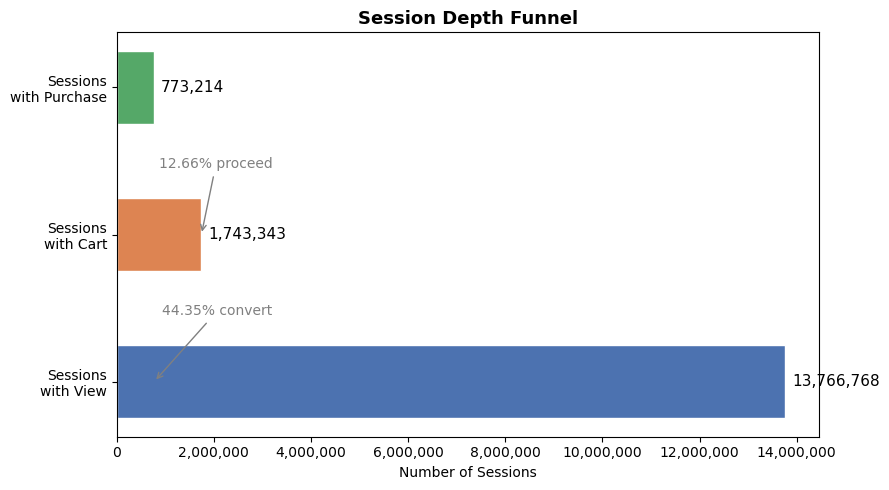

In [27]:
print("\n" + "─" * 60)
print("SESSION DEPTH FUNNEL")
print("─" * 60)
 
depth_funnel = q(f"""
    WITH s AS (
        SELECT user_session,
               MAX(CASE WHEN event_type='view'     THEN 1 ELSE 0 END) AS has_view,
               MAX(CASE WHEN event_type='cart'     THEN 1 ELSE 0 END) AS has_cart,
               MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS has_purchase
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
    )
    SELECT
        SUM(has_view)                          AS viewed,
        SUM(has_cart)                          AS carted,
        SUM(has_purchase)                      AS purchased,
        COUNT(*)                               AS total_sessions,
        ROUND(SUM(has_cart)*100.0    / NULLIF(SUM(has_view),0), 2) AS view_to_cart_pct,
        ROUND(SUM(has_purchase)*100.0/ NULLIF(SUM(has_cart),0), 2) AS cart_to_purchase_pct
    FROM s
""")
 
print(depth_funnel.T.to_string(header=False))
 
viewed    = int(depth_funnel["viewed"][0])
carted    = int(depth_funnel["carted"][0])
purchased = int(depth_funnel["purchased"][0])
v2c = float(depth_funnel["view_to_cart_pct"][0])
c2p = float(depth_funnel["cart_to_purchase_pct"][0])
 
fig, ax = plt.subplots(figsize=(9, 5))
stages  = ["Sessions\nwith View", "Sessions\nwith Cart", "Sessions\nwith Purchase"]
values  = [viewed, carted, purchased]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
bars    = ax.barh(stages, values, color=colors, edgecolor="white", height=0.5)
 
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=11)
 
ax.annotate(f"{v2c}% proceed", xy=(carted, 1), xytext=(carted * 0.5, 1.45),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10, color="gray")
ax.annotate(f"{c2p}% convert", xy=(purchased, 0), xytext=(purchased * 1.2, 0.45),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10, color="gray")
 
ax.set_title("Session Depth Funnel", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("Number of Sessions")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_session_depth_funnel.png", dpi=150)
plt.show(); 
plt.close()

Conversion per session


────────────────────────────────────────────────────────────
CONVERSION PER SESSION — BY CATEGORY
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

main_category  total_sessions  converted_sessions  conversion_rate_pct
  electronics         5970644            417753.0                 7.00
   appliances         1640688             88356.0                 5.39
     medicine            6227               330.0                 5.30
         auto          306982             10054.0                 3.28
    computers          930997             30137.0                 3.24
 construction          250428              7998.0                 3.19
   stationery            5187               159.0                 3.07
         kids          260637              5598.0                 2.15
    furniture          522785             10332.0                 1.98
  accessories          103288              2019.0                 1.95
        sport           72117              1368.0                 1.90
      apparel          696131             12659.0                 1.82
 country_yard            5880                60.0                 1.02


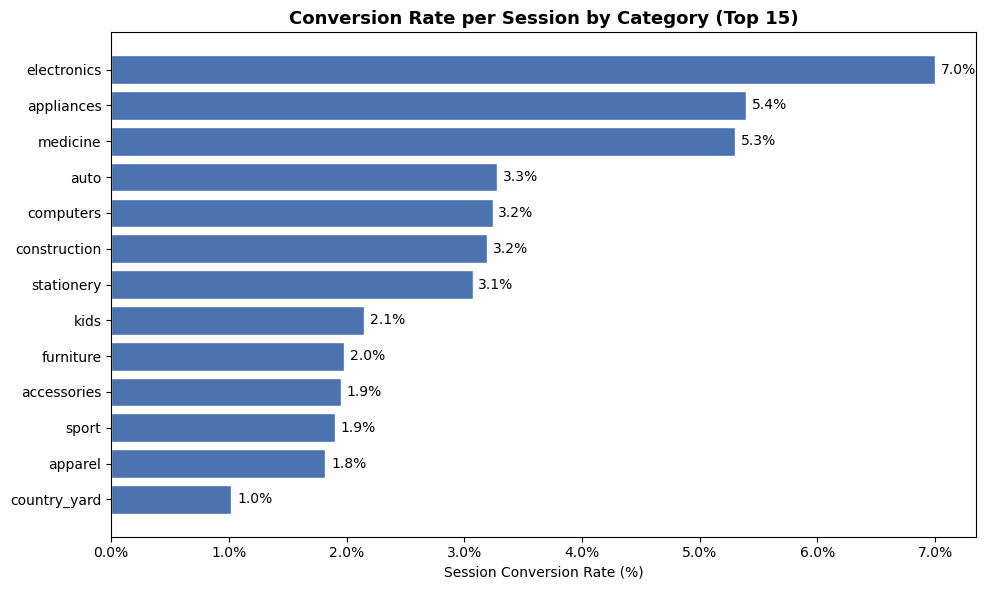

In [28]:
print("\n" + "─" * 60)
print("CONVERSION PER SESSION — BY CATEGORY")
print("─" * 60)
 
conv_per_session = q(f"""
    WITH s AS (
        SELECT
            user_session,
            {CAT_EXPR}                                         AS main_category,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS converted
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session, {CAT_EXPR}
    )
    SELECT main_category,
           COUNT(*)                            AS total_sessions,
           SUM(converted)                      AS converted_sessions,
           ROUND(AVG(converted) * 100, 2)      AS conversion_rate_pct
    FROM s
    WHERE main_category != 'unknown_category'
    GROUP BY 1
    HAVING total_sessions >= 500
    ORDER BY conversion_rate_pct DESC
    LIMIT 15
""")
 
print(conv_per_session.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 6))
conv_per_session_sorted = conv_per_session.sort_values("conversion_rate_pct")
bars = ax.barh(conv_per_session_sorted["main_category"],
               conv_per_session_sorted["conversion_rate_pct"],
               color="#4C72B0", edgecolor="white")
for bar, val in zip(bars, conv_per_session_sorted["conversion_rate_pct"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_title("Conversion Rate per Session by Category (Top 15)", fontsize=13, fontweight="bold")
ax.set_xlabel("Session Conversion Rate (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/15_conversion_per_session_category.png", dpi=150)
plt.show(); 
plt.close()

USER RETENTION — New vs Returning


────────────────────────────────────────────────────────────
USER RETENTION — NEW vs RETURNING
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

one_day_users          1995793.00
two_three_day_users    1046839.00
four_seven_day_users    496237.00
power_users             157248.00
total_users            3696117.00
avg_sessions_per_user        3.73
avg_events_per_user         18.26
avg_spend_per_buyer        623.12


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

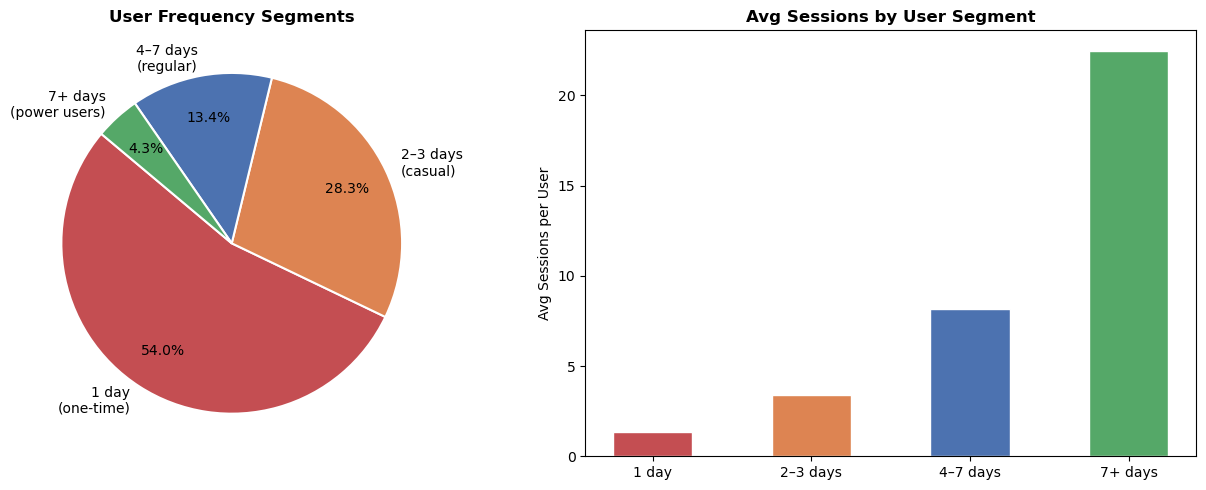

In [29]:
print("\n" + "─" * 60)
print("USER RETENTION — NEW vs RETURNING")
print("─" * 60)
 
user_retention = q(f"""
    WITH user_days AS (
        SELECT
            user_id,
            COUNT(DISTINCT strftime(event_time::TIMESTAMP, '%Y-%m-%d')) AS active_days,
            COUNT(DISTINCT user_session)                                 AS total_sessions,
            COUNT(*)                                                     AS total_events,
            SUM(CASE WHEN event_type='purchase' THEN price ELSE 0 END)  AS total_spent
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id
    )
    SELECT
        SUM(CASE WHEN active_days = 1 THEN 1 ELSE 0 END)  AS one_day_users,
        SUM(CASE WHEN active_days BETWEEN 2 AND 3
                 THEN 1 ELSE 0 END)                        AS two_three_day_users,
        SUM(CASE WHEN active_days BETWEEN 4 AND 7
                 THEN 1 ELSE 0 END)                        AS four_seven_day_users,
        SUM(CASE WHEN active_days > 7 THEN 1 ELSE 0 END)  AS power_users,
        COUNT(*)                                            AS total_users,
        ROUND(AVG(total_sessions), 2)                      AS avg_sessions_per_user,
        ROUND(AVG(total_events), 2)                        AS avg_events_per_user,
        ROUND(AVG(CASE WHEN total_spent > 0
              THEN total_spent END), 2)                    AS avg_spend_per_buyer
    FROM user_days
""")
 
print(user_retention.T.to_string(header=False))
 
one_day   = int(user_retention["one_day_users"][0])
two_three = int(user_retention["two_three_day_users"][0])
four_sev  = int(user_retention["four_seven_day_users"][0])
power     = int(user_retention["power_users"][0])
 
labels  = ["1 day\n(one-time)", "2–3 days\n(casual)", "4–7 days\n(regular)", "7+ days\n(power users)"]
sizes   = [one_day, two_three, four_sev, power]
colors  = ["#C44E52", "#DD8452", "#4C72B0", "#55A868"]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Pie chart
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=1.5))
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title("User Frequency Segments", fontweight="bold")
 
# Bar chart — avg sessions per segment
seg_detail = q(f"""
    WITH user_days AS (
        SELECT user_id,
               COUNT(DISTINCT strftime(event_time::TIMESTAMP,'%Y-%m-%d')) AS active_days,
               COUNT(DISTINCT user_session)  AS sessions,
               SUM(CASE WHEN event_type='purchase' THEN price ELSE 0 END) AS spent
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id
    )
    SELECT
        CASE
            WHEN active_days = 1          THEN '1 day'
            WHEN active_days BETWEEN 2 AND 3 THEN '2–3 days'
            WHEN active_days BETWEEN 4 AND 7 THEN '4–7 days'
            ELSE '7+ days'
        END AS segment,
        ROUND(AVG(sessions), 2) AS avg_sessions,
        ROUND(AVG(spent), 2)    AS avg_spent
    FROM user_days
    GROUP BY 1
    ORDER BY MIN(active_days)
""")
 
x = range(len(seg_detail))
axes[1].bar(x, seg_detail["avg_sessions"], color=colors, edgecolor="white", width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_detail["segment"])
axes[1].set_title("Avg Sessions by User Segment", fontweight="bold")
axes[1].set_ylabel("Avg Sessions per User")
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/16_user_retention_segments.png", dpi=150)
plt.show(); 
plt.close()

DAILY RETENTION COHORT(Which days of November retained users?)


────────────────────────────────────────────────────────────
DAILY USER RETENTION COHORT
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

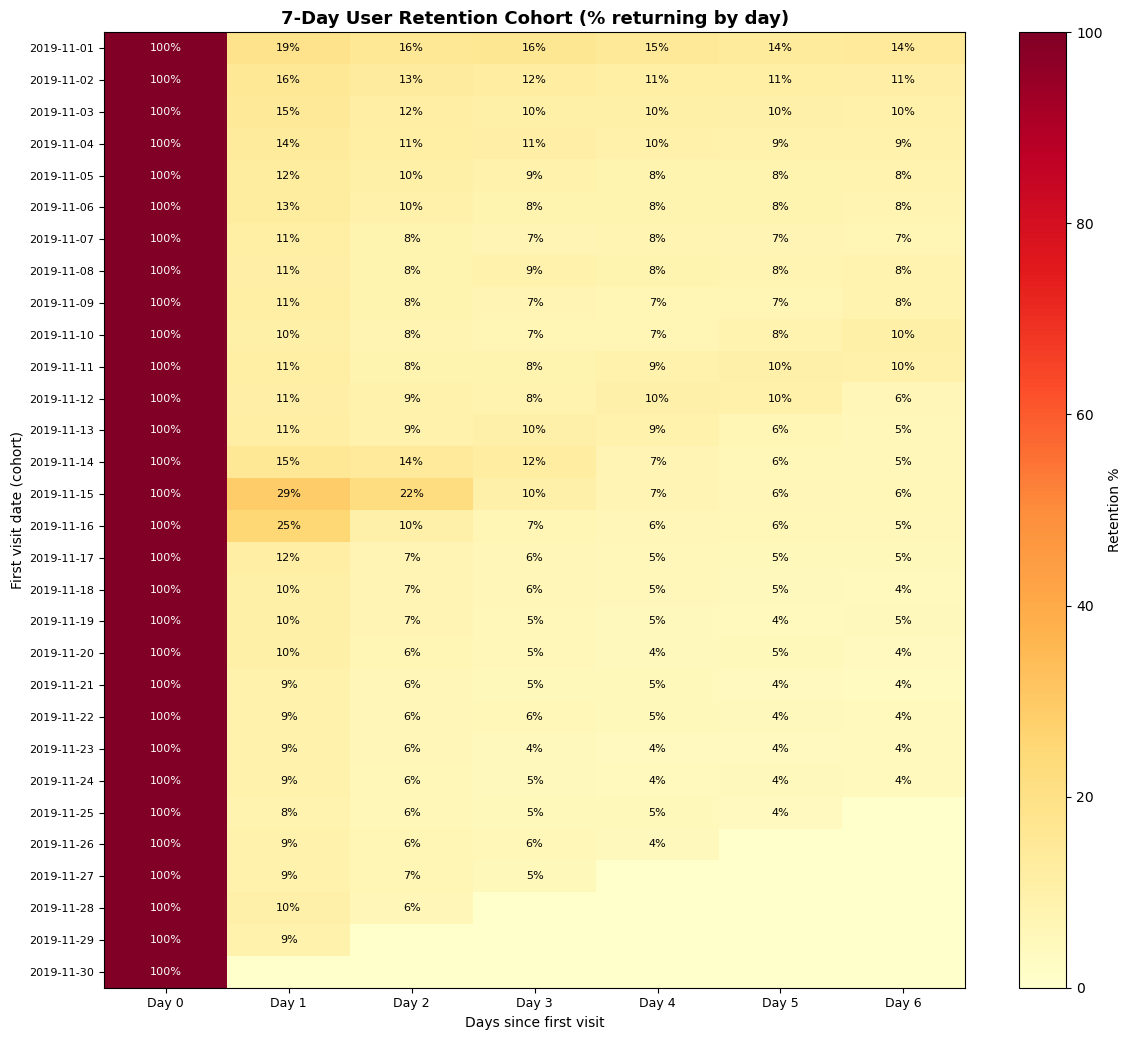

In [30]:
print("\n" + "─" * 60)
print("DAILY USER RETENTION COHORT")
print("─" * 60)
 
daily_retention = q(f"""
    WITH first_seen AS (
        SELECT user_id,
               MIN(strftime(event_time::TIMESTAMP,'%Y-%m-%d')) AS first_day
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id
    ),
    user_activity AS (
        SELECT DISTINCT user_id,
               strftime(event_time::TIMESTAMP,'%Y-%m-%d') AS active_day
        FROM read_csv_auto('{FILE_PATH}')
    ),
    cohort AS (
        SELECT f.first_day,
               u.active_day,
               DATEDIFF('day', f.first_day::DATE, u.active_day::DATE) AS day_number,
               COUNT(DISTINCT u.user_id) AS users
        FROM first_seen f
        JOIN user_activity u ON f.user_id = u.user_id
        WHERE DATEDIFF('day', f.first_day::DATE, u.active_day::DATE) BETWEEN 0 AND 6
        GROUP BY 1, 2, 3
    ),
    cohort_size AS (
        SELECT first_day, COUNT(DISTINCT user_id) AS cohort_users
        FROM first_seen
        GROUP BY first_day
    )
    SELECT c.first_day, c.day_number,
           ROUND(c.users * 100.0 / cs.cohort_users, 1) AS retention_pct
    FROM cohort c
    JOIN cohort_size cs ON c.first_day = cs.first_day
    ORDER BY c.first_day, c.day_number
""")
 
# Pivot into heatmap format
cohort_pivot = daily_retention.pivot(
    index="first_day", columns="day_number", values="retention_pct"
).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, max(6, len(cohort_pivot) * 0.35)))
im = ax.imshow(cohort_pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="Retention %")
 
ax.set_xticks(range(len(cohort_pivot.columns)))
ax.set_xticklabels([f"Day {d}" for d in cohort_pivot.columns], fontsize=9)
ax.set_yticks(range(len(cohort_pivot.index)))
ax.set_yticklabels(cohort_pivot.index, fontsize=8)
 
for i in range(len(cohort_pivot.index)):
    for j in range(len(cohort_pivot.columns)):
        val = cohort_pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=8, color="black" if val < 60 else "white")
 
ax.set_title("7-Day User Retention Cohort (% returning by day)", fontsize=13, fontweight="bold")
ax.set_xlabel("Days since first visit")
ax.set_ylabel("First visit date (cohort)")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/17_retention_cohort_heatmap.png", dpi=150)
plt.show(); 
plt.close()

SESSION SUMMARY TABLE

In [31]:
print("\n" + "─" * 60)
print("SESSION SUMMARY TABLE (top 20 power sessions)")
print("─" * 60)
 
top_sessions = q(f"""
    SELECT
        user_session,
        COUNT(*)                                              AS total_events,
        COUNT(DISTINCT event_type)                            AS event_types,
        ROUND(EPOCH(MAX(event_time::TIMESTAMP)
            - MIN(event_time::TIMESTAMP)) / 60.0, 1)         AS duration_mins,
        SUM(CASE WHEN event_type='view'
            THEN 1 ELSE 0 END)                               AS views,
        SUM(CASE WHEN event_type='cart'
            THEN 1 ELSE 0 END)                               AS carts,
        SUM(CASE WHEN event_type='purchase'
            THEN 1 ELSE 0 END)                               AS purchases,
        ROUND(SUM(CASE WHEN event_type='purchase'
            THEN price ELSE 0 END), 2)                       AS revenue
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY user_session
    ORDER BY total_events DESC
    LIMIT 20
""")
 
print(top_sessions.to_string(index=False))


────────────────────────────────────────────────────────────
SESSION SUMMARY TABLE (top 20 power sessions)
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                        user_session  total_events  event_types  duration_mins  views  carts  purchases  revenue
d99d91bf-40f8-4e29-9593-54b4a1826542          4128            1          249.8 4128.0    0.0        0.0     0.00
fc749a4e-c432-4dae-a0a1-04de89f1e4ea          2466            1          134.5 2466.0    0.0        0.0     0.00
b556f0c7-3a23-44f5-9f34-e713fefa9686          1963            1          105.6 1963.0    0.0        0.0     0.00
d6433d7b-3846-456a-88de-748c3fac2675          1658            1           90.6 1658.0    0.0        0.0     0.00
88206fc3-b5ea-4e3b-be68-67edfbf7009b          1373            1           85.2 1373.0    0.0        0.0     0.00
af4ad1c0-a131-4fab-94f2-5d6d647adcb7          1294            1           74.2 1294.0    0.0        0.0     0.00
0c307610-aa79-bf12-4ada-323af26b44b9           918            1          763.5  918.0    0.0        0.0     0.00
8c322efd-e368-42ae-9b71-37351e74ec55           711            2            1.2    2.0  709.0    

EXPORT SESSION DATA TO EXCEL

In [32]:
print("EXPORTING SESSION + RETENTION DATA TO EXCEL")
print("─" * 60)
 
with pd.ExcelWriter(f"{OUTPUT_DIR}/session_retention_analysis.xlsx",
                    engine="openpyxl") as writer:
    session_metrics.T.reset_index().to_excel(
        writer, sheet_name="Session Metrics", index=False,
        header=["Metric", "Value"])
    depth_funnel.T.reset_index().to_excel(
        writer, sheet_name="Session Depth Funnel", index=False,
        header=["Metric", "Value"])
    conv_per_session.to_excel(
        writer, sheet_name="Conv Per Session", index=False)
    user_retention.T.reset_index().to_excel(
        writer, sheet_name="User Retention", index=False,
        header=["Metric", "Value"])
    daily_retention.to_excel(
        writer, sheet_name="Cohort Retention", index=False)
    top_sessions.to_excel(
        writer, sheet_name="Top Sessions", index=False)
    seg_detail.to_excel(
        writer, sheet_name="User Segments", index=False)
 
print(f"  ✔ session_retention_analysis.xlsx saved to ./{OUTPUT_DIR}/")

EXPORTING SESSION + RETENTION DATA TO EXCEL
────────────────────────────────────────────────────────────
  ✔ session_retention_analysis.xlsx saved to ./product_analysis_output/


SESSION & RETENTION SUMMARY PRINT

In [33]:
print("\n" + "=" * 60)
print("  SESSION & RETENTION SUMMARY")
print("=" * 60)
print(f"  Total sessions           : {int(session_metrics['total_sessions'][0]):,}")
print(f"  Avg events / session     : {float(session_metrics['avg_events_per_session'][0]):.2f}")
print(f"  Avg session length       : {float(session_metrics['avg_session_length_mins'][0]):.2f} mins")
print(f"  Median session length    : {float(session_metrics['median_session_length_mins'][0]):.2f} mins")
print(f"  Sessions that converted  : {float(session_metrics['pct_sessions_converted'][0]):.2f}%")
print(f"  Sessions that carted     : {float(session_metrics['pct_sessions_carted'][0]):.2f}%")
print(f"  Avg revenue (converters) : ${float(session_metrics['avg_revenue_per_converting_session'][0]):,.2f}")
print(f"  Total unique users       : {int(user_retention['total_users'][0]):,}")
print(f"  Avg sessions / user      : {float(user_retention['avg_sessions_per_user'][0]):.2f}")
print(f"  Avg spend / buyer        : ${float(user_retention['avg_spend_per_buyer'][0]):,.2f}")
print(f"\n  Charts saved to          : ./{OUTPUT_DIR}/")
print(f"  Excel saved to           : ./{OUTPUT_DIR}/session_retention_analysis.xlsx")
print("=" * 60)


  SESSION & RETENTION SUMMARY
  Total sessions           : 13,776,051
  Avg events / session     : 4.90
  Avg session length       : 15.52 mins
  Median session length    : 1.00 mins
  Sessions that converted  : 5.61%
  Sessions that carted     : 12.65%
  Avg revenue (converters) : $355.91
  Total unique users       : 3,696,117
  Avg sessions / user      : 3.73
  Avg spend / buyer        : $623.12

  Charts saved to          : ./product_analysis_output/
  Excel saved to           : ./product_analysis_output/session_retention_analysis.xlsx


In [34]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from datetime import datetime

In [35]:
print("\n" + "=" * 60)
print("  CART ABANDONMENT ANALYSIS")
print("=" * 60)
 
cart_overview = q(f"""
    WITH session_cart AS (
        SELECT
            user_session,
            MAX(CASE WHEN event_type = 'cart'     THEN 1 ELSE 0 END) AS carted,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchased,
            COUNT(DISTINCT CASE WHEN event_type = 'cart'
                  THEN product_id END)                                AS cart_products,
            SUM(CASE WHEN event_type = 'cart'
                THEN price ELSE 0 END)                                AS cart_value,
            SUM(CASE WHEN event_type = 'purchase'
                THEN price ELSE 0 END)                                AS purchase_value
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
    )
    SELECT
        COUNT(*)                                           AS total_sessions,
        SUM(carted)                                        AS sessions_with_cart,
        SUM(CASE WHEN carted=1 AND purchased=1 THEN 1
                 ELSE 0 END)                               AS cart_and_purchased,
        SUM(CASE WHEN carted=1 AND purchased=0 THEN 1
                 ELSE 0 END)                               AS cart_abandoned,
        ROUND(SUM(CASE WHEN carted=1 AND purchased=0
              THEN 1 ELSE 0 END) * 100.0
              / NULLIF(SUM(carted), 0), 2)                 AS abandonment_rate_pct,
        ROUND(AVG(CASE WHEN carted=1
              THEN cart_value END), 2)                     AS avg_cart_value,
        ROUND(AVG(CASE WHEN carted=1 AND purchased=0
              THEN cart_value END), 2)                     AS avg_abandoned_cart_value,
        ROUND(SUM(CASE WHEN carted=1 AND purchased=0
              THEN cart_value ELSE 0 END), 2)              AS total_abandoned_revenue
    FROM session_cart
""")
 
print("\n  Cart Abandonment Overview:")
print(cart_overview.T.to_string(header=False))
 
sessions_with_cart  = int(cart_overview["sessions_with_cart"][0])
cart_and_purchased  = int(cart_overview["cart_and_purchased"][0])
cart_abandoned      = int(cart_overview["cart_abandoned"][0])
abandonment_rate    = float(cart_overview["abandonment_rate_pct"][0])
avg_cart_val        = float(cart_overview["avg_cart_value"][0])
avg_abandoned_val   = float(cart_overview["avg_abandoned_cart_value"][0])
total_abandoned_rev = float(cart_overview["total_abandoned_revenue"][0])


  CART ABANDONMENT ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Cart Abandonment Overview:
total_sessions            1.377605e+07
sessions_with_cart        1.743343e+06
cart_and_purchased        6.483630e+05
cart_abandoned            1.094980e+06
abandonment_rate_pct      6.281000e+01
avg_cart_value            5.038100e+02
avg_abandoned_cart_value  4.868900e+02
total_abandoned_revenue   5.331350e+08


Abandonment funnel chart and rate donut chart

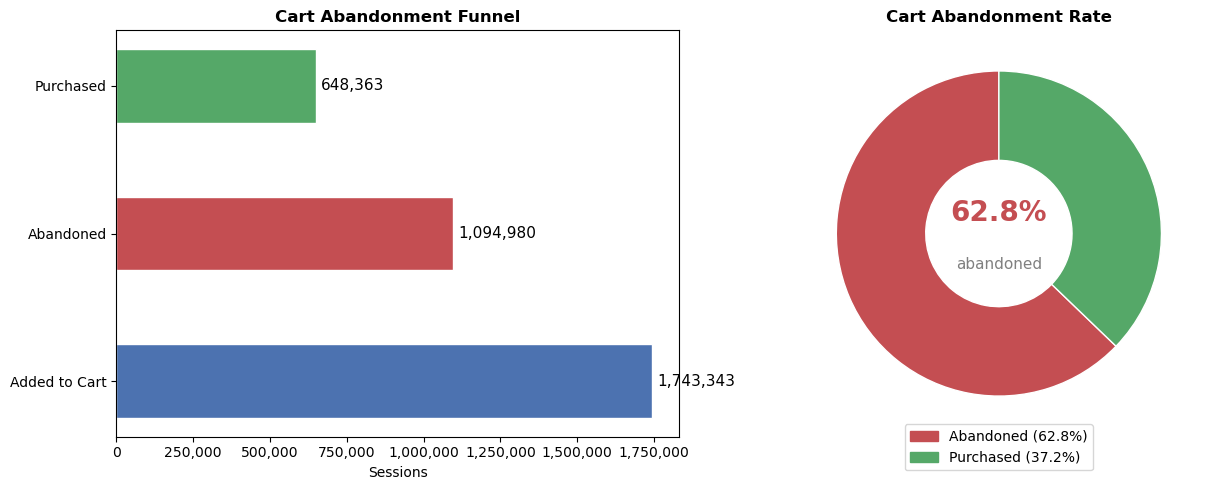

In [36]:
# ── Abandonment funnel chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
funnel_labels  = ["Added to Cart", "Abandoned", "Purchased"]
funnel_values  = [sessions_with_cart, cart_abandoned, cart_and_purchased]
funnel_colors  = ["#4C72B0", "#C44E52", "#55A868"]
bars = axes[0].barh(funnel_labels, funnel_values,
                    color=funnel_colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, funnel_values):
    axes[0].text(bar.get_width() + max(funnel_values)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=11)
axes[0].set_title("Cart Abandonment Funnel", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_xlabel("Sessions")
 
# Abandonment rate donut
sizes  = [abandonment_rate, 100 - abandonment_rate]
colors = ["#C44E52", "#55A868"]
wedges, _ = axes[1].pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.55, edgecolor="white"))
axes[1].text(0, 0.08, f"{abandonment_rate:.1f}%", ha="center",
             fontsize=20, fontweight="bold", color="#C44E52")
axes[1].text(0, -0.22, "abandoned", ha="center", fontsize=11,
             color="gray")
legend_patches = [
    mpatches.Patch(color="#C44E52", label=f"Abandoned ({abandonment_rate:.1f}%)"),
    mpatches.Patch(color="#55A868", label=f"Purchased ({100-abandonment_rate:.1f}%)")
]
axes[1].legend(handles=legend_patches, loc="lower center",
               bbox_to_anchor=(0.5, -0.1), fontsize=10)
axes[1].set_title("Cart Abandonment Rate", fontweight="bold")
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/18_cart_abandonment_funnel.png", dpi=150)
plt.show(); plt.close()

ABANDONMENT BY CATEGORY


────────────────────────────────────────────────────────────
CART ABANDONMENT BY CATEGORY
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

main_category  cart_sessions  abandoned  abandonment_rate_pct  avg_abandoned_value
 country_yard          220.0      169.0                 76.82               365.49
   stationery          423.0      309.0                 73.05                25.39
    furniture        26986.0    19065.0                 70.65               354.02
      apparel        33983.0    23852.0                 70.19               129.27
        sport         3791.0     2649.0                 69.88               431.16
 construction        21465.0    14794.0                 68.92               221.07
  accessories         5120.0     3509.0                 68.54                70.75
    computers        75061.0    50590.0                 67.40               653.82
         kids        13357.0     8968.0                 67.14               177.76
         auto        24615.0    16218.0                 65.89               203.47
   appliances       206109.0   133533.0                 64.79               343.20
    

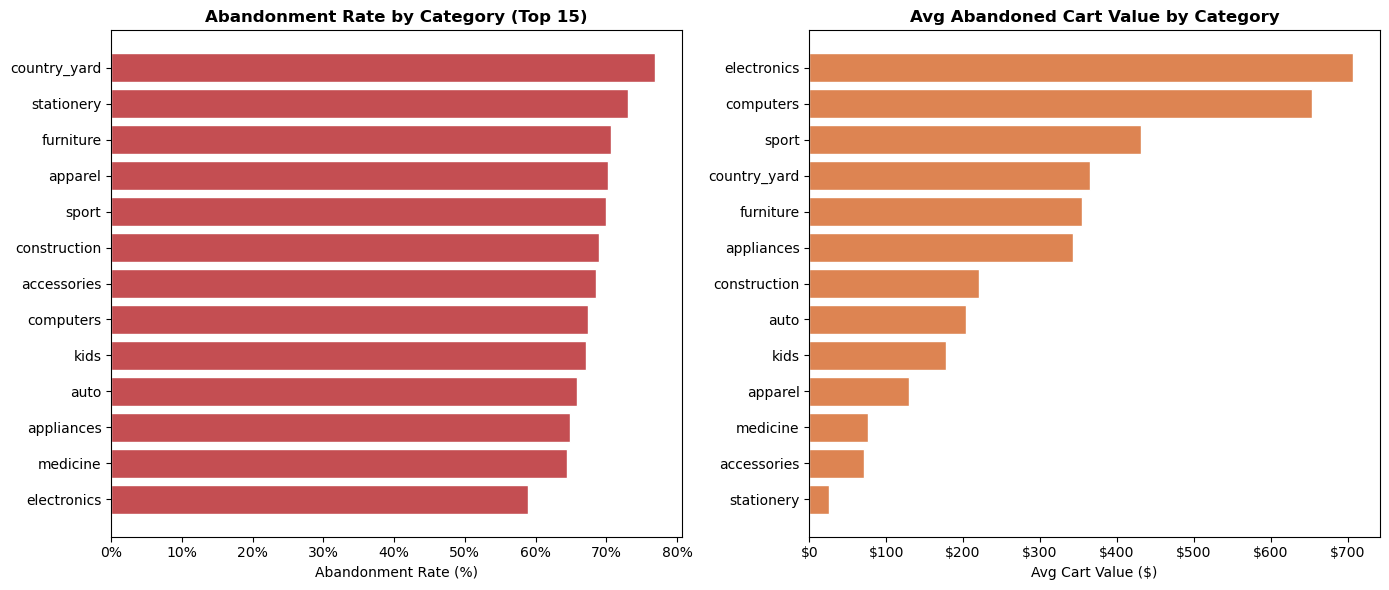

In [37]:
print("\n" + "─" * 60)
print("CART ABANDONMENT BY CATEGORY")
print("─" * 60)
 
cat_abandonment = q(f"""
    WITH session_cat AS (
        SELECT
            user_session,
            {CAT_EXPR}                                         AS main_category,
            MAX(CASE WHEN event_type='cart'
                THEN 1 ELSE 0 END)                             AS carted,
            MAX(CASE WHEN event_type='purchase'
                THEN 1 ELSE 0 END)                             AS purchased,
            SUM(CASE WHEN event_type='cart'
                THEN price ELSE 0 END)                         AS cart_value
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session, {CAT_EXPR}
    )
    SELECT
        main_category,
        SUM(carted)                                            AS cart_sessions,
        SUM(CASE WHEN carted=1 AND purchased=0
            THEN 1 ELSE 0 END)                                 AS abandoned,
        ROUND(SUM(CASE WHEN carted=1 AND purchased=0
              THEN 1 ELSE 0 END) * 100.0
              / NULLIF(SUM(carted), 0), 2)                     AS abandonment_rate_pct,
        ROUND(AVG(CASE WHEN carted=1 AND purchased=0
              THEN cart_value END), 2)                         AS avg_abandoned_value
    FROM session_cat
    WHERE main_category != 'unknown_category'
    GROUP BY 1
    HAVING cart_sessions >= 200
    ORDER BY abandonment_rate_pct DESC
    LIMIT 15
""")
 
print(cat_abandonment.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
cat_aband_sorted = cat_abandonment.sort_values("abandonment_rate_pct")
axes[0].barh(cat_aband_sorted["main_category"],
             cat_aband_sorted["abandonment_rate_pct"],
             color="#C44E52", edgecolor="white")
axes[0].set_title("Abandonment Rate by Category (Top 15)", fontweight="bold")
axes[0].set_xlabel("Abandonment Rate (%)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
 
cat_aband_val = cat_abandonment.sort_values("avg_abandoned_value").dropna(
    subset=["avg_abandoned_value"])
axes[1].barh(cat_aband_val["main_category"],
             cat_aband_val["avg_abandoned_value"],
             color="#DD8452", edgecolor="white")
axes[1].set_title("Avg Abandoned Cart Value by Category", fontweight="bold")
axes[1].set_xlabel("Avg Cart Value ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/19_abandonment_by_category.png", dpi=150)
plt.show();
plt.close()

ABANDONMENT BY PRICE RANGE


────────────────────────────────────────────────────────────
CART ABANDONMENT BY PRICE RANGE
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

price_range  sort_order  cart_sessions  abandoned  abandonment_rate_pct
  Under $10           1          34451    25712.0                 74.63
    $10–$50           2         276762   184454.0                 66.65
   $50–$100           3         227772   148654.0                 65.26
  $100–$250           4         584264   347505.0                 59.48
  $250–$500           5         315672   198469.0                 62.87
  Over $500           6         304422   190186.0                 62.47


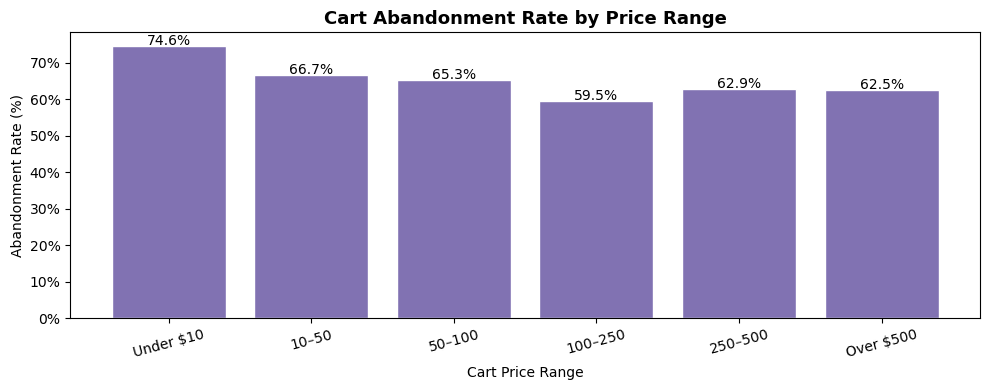

In [38]:
print("\n" + "─" * 60)
print("CART ABANDONMENT BY PRICE RANGE")
print("─" * 60)
 
price_abandonment = q(f"""
    WITH session_price AS (
        SELECT
            user_session,
            AVG(CASE WHEN event_type='cart' THEN price END) AS avg_cart_price,
            MAX(CASE WHEN event_type='cart'
                THEN 1 ELSE 0 END)                          AS carted,
            MAX(CASE WHEN event_type='purchase'
                THEN 1 ELSE 0 END)                          AS purchased
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_session
        HAVING carted = 1
    )
    SELECT
        CASE
            WHEN avg_cart_price < 10   THEN 'Under $10'
            WHEN avg_cart_price < 50   THEN '$10–$50'
            WHEN avg_cart_price < 100  THEN '$50–$100'
            WHEN avg_cart_price < 250  THEN '$100–$250'
            WHEN avg_cart_price < 500  THEN '$250–$500'
            ELSE 'Over $500'
        END AS price_range,
        CASE
            WHEN avg_cart_price < 10   THEN 1
            WHEN avg_cart_price < 50   THEN 2
            WHEN avg_cart_price < 100  THEN 3
            WHEN avg_cart_price < 250  THEN 4
            WHEN avg_cart_price < 500  THEN 5
            ELSE 6
        END AS sort_order,
        COUNT(*)                                            AS cart_sessions,
        SUM(CASE WHEN purchased=0 THEN 1 ELSE 0 END)       AS abandoned,
        ROUND(SUM(CASE WHEN purchased=0 THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 2)                        AS abandonment_rate_pct
    FROM session_price
    GROUP BY 1, 2
    ORDER BY sort_order
""")
 
print(price_abandonment.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(price_abandonment["price_range"],
              price_abandonment["abandonment_rate_pct"],
              color="#8172B2", edgecolor="white")
for bar, val in zip(bars, price_abandonment["abandonment_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10)
ax.set_title("Cart Abandonment Rate by Price Range", fontsize=13, fontweight="bold")
ax.set_xlabel("Cart Price Range")
ax.set_ylabel("Abandonment Rate (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/20_abandonment_by_price.png", dpi=150)
plt.show(); 
plt.close()


TIME-TO-PURCHASE ANALYSIS
(How long from first view to purchase?)

In [39]:
print("\n" + "=" * 60)
print("  TIME-TO-PURCHASE ANALYSIS")
print("=" * 60)
 
ttp_stats = q(f"""
    WITH user_journey AS (
        SELECT
            user_id,
            product_id,
            MIN(CASE WHEN event_type='view'
                THEN event_time::TIMESTAMP END)              AS first_view,
            MIN(CASE WHEN event_type='purchase'
                THEN event_time::TIMESTAMP END)              AS purchase_time
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id, product_id
        HAVING first_view IS NOT NULL AND purchase_time IS NOT NULL
           AND purchase_time >= first_view
    )
    SELECT
        COUNT(*)                                             AS total_journeys,
        ROUND(AVG(EPOCH(purchase_time - first_view)/60), 2) AS avg_mins_to_purchase,
        ROUND(MEDIAN(EPOCH(purchase_time - first_view)/60),2) AS median_mins_to_purchase,
        ROUND(AVG(EPOCH(purchase_time - first_view)/3600),2) AS avg_hours_to_purchase,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP
              (ORDER BY EPOCH(purchase_time - first_view)/60),2) AS p25_mins,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP
              (ORDER BY EPOCH(purchase_time - first_view)/60),2) AS p75_mins,
        ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP
              (ORDER BY EPOCH(purchase_time - first_view)/60),2) AS p90_mins
    FROM user_journey
""")
 
print("\n  Time-to-Purchase Stats:")
print(ttp_stats.T.to_string(header=False))


  TIME-TO-PURCHASE ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Time-to-Purchase Stats:
total_journeys           717608.00
avg_mins_to_purchase       1407.88
median_mins_to_purchase       4.67
avg_hours_to_purchase        23.46
p25_mins                      1.80
p75_mins                     64.70
p90_mins                   3473.77


Time to purchase distribution buckets

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Time-to-Purchase Distribution:
time_bucket  journeys
Under 1 min     90704
   1–5 mins    278998
  5–15 mins    113714
 15–30 mins     32997
 30–60 mins     20064
  1–6 hours     34821
 6–24 hours     39283
 Over 1 day    107027


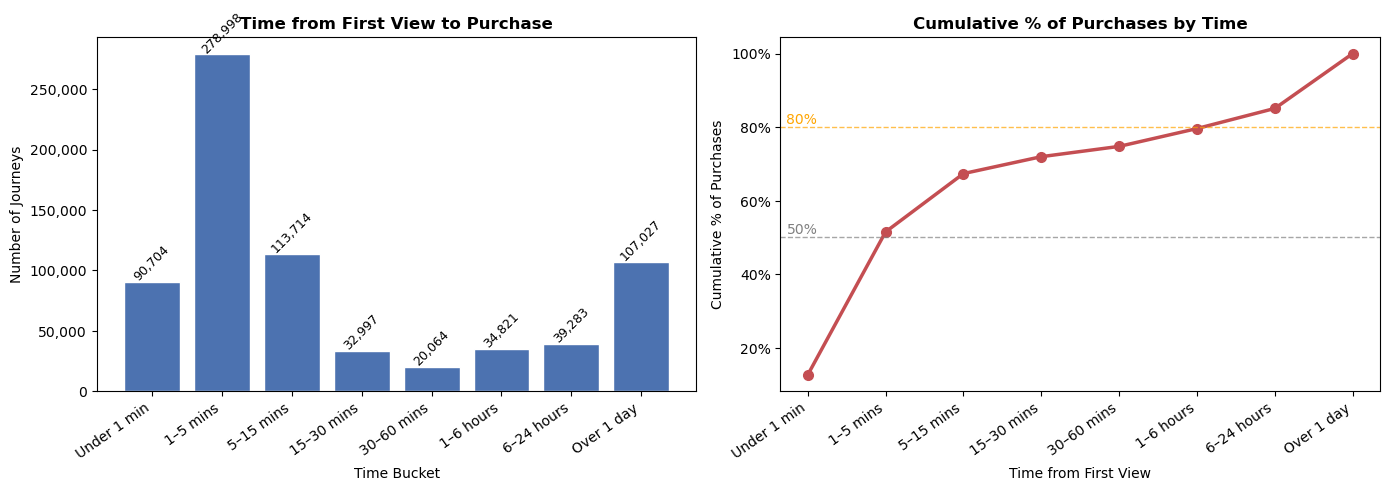

In [40]:
ttp_dist = q(f"""
    WITH user_journey AS (
        SELECT
            user_id, product_id,
            MIN(CASE WHEN event_type='view'
                THEN event_time::TIMESTAMP END)    AS first_view,
            MIN(CASE WHEN event_type='purchase'
                THEN event_time::TIMESTAMP END)    AS purchase_time
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id, product_id
        HAVING first_view IS NOT NULL
           AND purchase_time IS NOT NULL
           AND purchase_time >= first_view
    ),
    with_duration AS (
        SELECT EPOCH(purchase_time - first_view)/60 AS mins
        FROM user_journey
    )
    SELECT
        CASE
            WHEN mins < 1    THEN 'Under 1 min'
            WHEN mins < 5    THEN '1–5 mins'
            WHEN mins < 15   THEN '5–15 mins'
            WHEN mins < 30   THEN '15–30 mins'
            WHEN mins < 60   THEN '30–60 mins'
            WHEN mins < 360  THEN '1–6 hours'
            WHEN mins < 1440 THEN '6–24 hours'
            ELSE 'Over 1 day'
        END AS time_bucket,
        CASE
            WHEN mins < 1    THEN 1
            WHEN mins < 5    THEN 2
            WHEN mins < 15   THEN 3
            WHEN mins < 30   THEN 4
            WHEN mins < 60   THEN 5
            WHEN mins < 360  THEN 6
            WHEN mins < 1440 THEN 7
            ELSE 8
        END AS sort_order,
        COUNT(*) AS journeys
    FROM with_duration
    GROUP BY 1, 2
    ORDER BY sort_order
""")
 
print("\n  Time-to-Purchase Distribution:")
print(ttp_dist[["time_bucket","journeys"]].to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
bars = axes[0].bar(ttp_dist["time_bucket"], ttp_dist["journeys"],
                   color="#4C72B0", edgecolor="white")
for bar, val in zip(bars, ttp_dist["journeys"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(ttp_dist["journeys"])*0.005,
                 f"{val:,}", ha="center", fontsize=9, rotation=45)
axes[0].set_title("Time from First View to Purchase", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Time Bucket")
axes[0].set_ylabel("Number of Journeys")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=35, ha="right")
 
# Cumulative % line
ttp_dist["cumulative_pct"] = (ttp_dist["journeys"].cumsum()
                               / ttp_dist["journeys"].sum() * 100)
axes[1].plot(ttp_dist["time_bucket"], ttp_dist["cumulative_pct"],
             color="#C44E52", linewidth=2.5, marker="o", markersize=7)
axes[1].axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[1].axhline(y=80, color="orange", linestyle="--", linewidth=1, alpha=0.7)
axes[1].text(0.01, 51, "50%", transform=axes[1].get_yaxis_transform(),
             color="gray", fontsize=10)
axes[1].text(0.01, 81, "80%", transform=axes[1].get_yaxis_transform(),
             color="orange", fontsize=10)
axes[1].set_title("Cumulative % of Purchases by Time", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Time from First View")
axes[1].set_ylabel("Cumulative % of Purchases")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha="right")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/21_time_to_purchase.png", dpi=150)
plt.show(); plt.close()

Time to Purchase by category


────────────────────────────────────────────────────────────
TIME-TO-PURCHASE BY CATEGORY
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

main_category  journeys  median_mins  avg_mins
  electronics    361360          3.9    1524.7
      apparel     12179          4.7     975.2
    computers     27945          4.7    1349.5
   appliances     85063          6.1    1175.9
         kids      5105          6.4    1511.0
         auto      9087          7.0    1643.8
        sport      1223          7.2    1360.5
   stationery       168          7.3    1425.7
     medicine       304          7.5    1326.5
 construction      7376          8.0    1437.1
  accessories      1859          8.4    1515.8
    furniture      9691          9.7    1552.1


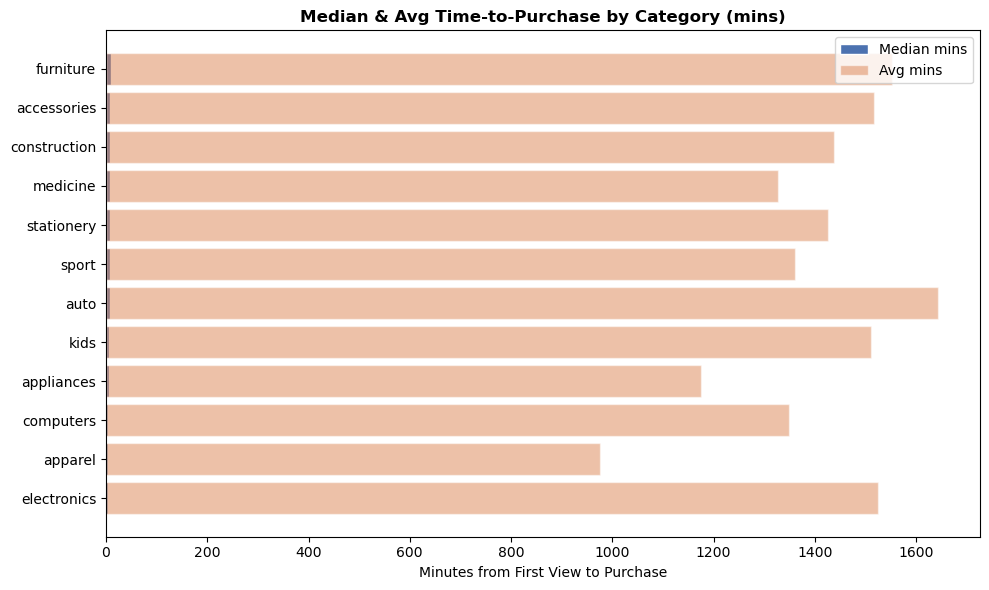

In [41]:
print("\n" + "─" * 60)
print("TIME-TO-PURCHASE BY CATEGORY")
print("─" * 60)
 
ttp_by_cat = q(f"""
    WITH user_journey AS (
        SELECT
            user_id,
            product_id,
            {CAT_EXPR}                                        AS main_category,
            MIN(CASE WHEN event_type='view'
                THEN event_time::TIMESTAMP END)               AS first_view,
            MIN(CASE WHEN event_type='purchase'
                THEN event_time::TIMESTAMP END)               AS purchase_time
        FROM read_csv_auto('{FILE_PATH}')
        GROUP BY user_id, product_id, {CAT_EXPR}
        HAVING first_view IS NOT NULL
           AND purchase_time IS NOT NULL
           AND purchase_time >= first_view
    )
    SELECT
        main_category,
        COUNT(*)                                              AS journeys,
        ROUND(MEDIAN(EPOCH(purchase_time - first_view)/60),1) AS median_mins,
        ROUND(AVG(EPOCH(purchase_time - first_view)/60),1)    AS avg_mins
    FROM user_journey
    WHERE main_category != 'unknown_category'
    GROUP BY 1
    HAVING journeys >= 100
    ORDER BY median_mins ASC
    LIMIT 15
""")
 
print(ttp_by_cat.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 6))
ttp_sorted = ttp_by_cat.sort_values("median_mins", ascending=True)
ax.barh(ttp_sorted["main_category"], ttp_sorted["median_mins"],
        color="#4C72B0", edgecolor="white", label="Median mins")
ax.barh(ttp_sorted["main_category"], ttp_sorted["avg_mins"],
        color="#DD8452", edgecolor="white", alpha=0.5, label="Avg mins")
ax.set_title("Median & Avg Time-to-Purchase by Category (mins)", fontsize=12, fontweight="bold")
ax.set_xlabel("Minutes from First View to Purchase")
ax.legend()
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/22_ttp_by_category.png", dpi=150)
plt.show(); plt.close()

DAY OF WEEK PURCHASE PATTERN


────────────────────────────────────────────────────────────
PURCHASE PATTERN BY DAY OF WEEK
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

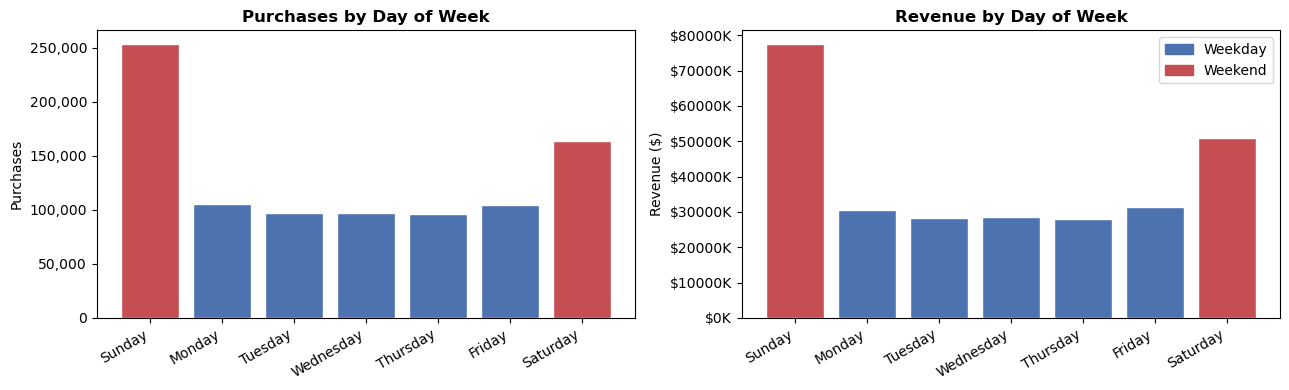

In [42]:
print("\n" + "─" * 60)
print("PURCHASE PATTERN BY DAY OF WEEK")
print("─" * 60)
 
dow_pattern = q(f"""
    SELECT
        DAYOFWEEK(event_time::TIMESTAMP)                     AS dow_num,
        CASE DAYOFWEEK(event_time::TIMESTAMP)
            WHEN 0 THEN 'Sunday'    WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'   WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'  WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END                                                  AS day_name,
        COUNT(*) FILTER (WHERE event_type='purchase')        AS purchases,
        ROUND(SUM(price) FILTER (WHERE event_type='purchase'),2) AS revenue
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY 1, 2
    ORDER BY 1
""")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bar_colors = ["#C44E52" if d in ["Saturday","Sunday"] else "#4C72B0"
              for d in dow_pattern["day_name"]]
 
axes[0].bar(dow_pattern["day_name"], dow_pattern["purchases"],
            color=bar_colors, edgecolor="white")
axes[0].set_title("Purchases by Day of Week", fontweight="bold")
axes[0].set_ylabel("Purchases")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")
 
axes[1].bar(dow_pattern["day_name"], dow_pattern["revenue"],
            color=bar_colors, edgecolor="white")
axes[1].set_title("Revenue by Day of Week", fontweight="bold")
axes[1].set_ylabel("Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
 
weekend_patch = mpatches.Patch(color="#C44E52", label="Weekend")
weekday_patch = mpatches.Patch(color="#4C72B0", label="Weekday")
axes[1].legend(handles=[weekday_patch, weekend_patch])
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/23_dow_purchase_pattern.png", dpi=150)
plt.show(); 
plt.close()

FINAL SECTION — BUSINESS INSIGHTS

In [44]:
peak_hour = q(f"""
    SELECT EXTRACT(hour FROM event_time::TIMESTAMP)::INT AS hour, COUNT(*) AS cnt
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY 1 ORDER BY cnt DESC LIMIT 1
""")
peak_hr = int(peak_hour["hour"][0])
peak_label = f"{peak_hr:02d}:00–{peak_hr+1:02d}:00"
 
peak_dow = dow_pattern.sort_values("purchases", ascending=False).iloc[0]
 
top_aband_cat = cat_abandonment.sort_values(
    "abandonment_rate_pct", ascending=False).iloc[0]
top_conv_cat  = conv_per_session.sort_values(
    "conversion_rate_pct", ascending=False).iloc[0]
low_conv_cat  = conv_per_session.sort_values(
    "conversion_rate_pct", ascending=True).iloc[0]
 
missing_cat_pct  = round(missing_cat / total_rows * 100, 1)
missing_brand_pct = round(missing_brand / total_rows * 100, 1)
 
median_ttp = float(ttp_stats["median_mins_to_purchase"][0])
pct_quick  = float(ttp_dist[ttp_dist["time_bucket"] == "Under 1 min"]["journeys"].sum()
                   / ttp_dist["journeys"].sum() * 100)
 
avg_events   = float(session_metrics["avg_events_per_session"][0])
avg_sess_len = float(session_metrics["avg_session_length_mins"][0])
pct_conv_sess = float(session_metrics["pct_sessions_converted"][0])
avg_rev_conv = float(session_metrics["avg_revenue_per_converting_session"][0])
 
print("\n" + "=" * 60)
print("  BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

insights = [
    # ── CART ABANDONMENT ──────────────────────
    (
        "CART ABANDONMENT",
        f"Abandonment rate is {abandonment_rate:.1f}% — "
        f"{cart_abandoned:,} sessions added to cart but never purchased.",
        f"  → Implement cart recovery emails / push notifications.\n"
        f"  → Offer a one-click checkout to reduce friction.\n"
        f"  → '{top_aband_cat['main_category']}' has the highest abandonment "
        f"({top_aband_cat['abandonment_rate_pct']:.1f}%) — review its pricing or "
        f"checkout flow first.\n"
        f"  → Estimated recoverable revenue: "
        f"${total_abandoned_rev:,.0f} (even 10% recovery = "
        f"${total_abandoned_rev*0.10:,.0f})."
    ),
    # ── CONVERSION ────────────────────────────
    (
        "CONVERSION GAP",
        f"Only {view_to_purchase:.2f}% of views result in a purchase. "
        f"View-to-cart is {view_to_cart:.2f}% and cart-to-purchase is "
        f"{cart_to_purchase:.2f}%.",
        f"  → The bigger drop happens at cart → purchase ({cart_to_purchase:.1f}%), "
        f"not view → cart — focus on checkout UX, not product discovery.\n"
        f"  → '{low_conv_cat['main_category']}' has the lowest session conversion "
        f"({low_conv_cat['conversion_rate_pct']:.2f}%) — likely a pricing or "
        f"trust issue.\n"
        f"  → '{top_conv_cat['main_category']}' converts best "
        f"({top_conv_cat['conversion_rate_pct']:.2f}%) — study what works there "
        f"and apply to weaker categories."
    ),
    # ── TIME-TO-PURCHASE ──────────────────────
    (
        "TIME-TO-PURCHASE",
        f"Median time from first view to purchase is {median_ttp:.1f} minutes. "
        f"{pct_quick:.1f}% of purchases happen within 1 minute of viewing.",
        f"  → {pct_quick:.0f}% impulse buyers decide instantly — ensure product pages "
        f"load fast and price is visible immediately.\n"
        f"  → For longer journeys, retargeting ads and wishlist reminders can "
        f"bring back undecided users.\n"
        f"  → '{ttp_by_cat.sort_values('median_mins',ascending=False).iloc[0]['main_category']}' "
        f"takes the longest to convert — consider comparison tools or "
        f"trust badges for high-consideration products."
    ),
    # ── TIMING ────────────────────────────────
    (
        "PURCHASE TIMING",
        f"Peak purchase hour is {peak_label} UTC. "
        f"Best day of week is {peak_dow['day_name']} "
        f"({int(peak_dow['purchases']):,} purchases).",
        f"  → Schedule ad campaigns and email sends to arrive 1–2 hours before "
        f"{peak_label}.\n"
        f"  → Run flash sales or limited-time offers on {peak_dow['day_name']} "
        f"to ride the natural demand peak.\n"
        f"  → Ensure servers and support teams are staffed during peak windows."
    ),
    # ── SESSION QUALITY ───────────────────────
    (
        "SESSION QUALITY",
        f"Avg session has {avg_events:.1f} events and lasts {avg_sess_len:.1f} mins. "
        f"Only {pct_conv_sess:.2f}% of sessions result in a purchase.",
        f"  → Sessions that convert spend ${avg_rev_conv:.2f} on average — "
        f"focus on increasing session depth (views per session).\n"
        f"  → Add product recommendations and 'customers also viewed' widgets "
        f"to increase events per session.\n"
        f"  → Sessions with 1 event are bounces — improve landing page relevance "
        f"and load speed."
    ),
    # ── DATA QUALITY ──────────────────────────
    (
        "DATA QUALITY",
        f"{missing_cat_pct:.1f}% of rows have no category_code and "
        f"{missing_brand_pct:.1f}% have no brand.",
        f"  → Missing brand reduces trust signals — work with suppliers to "
        f"ensure all products have brand metadata.\n"
        f"  → Missing category_code breaks recommendation engines and "
        f"search filters — audit product ingestion pipeline.\n"
        f"  → Products without brand/category likely have lower conversion — "
        f"prioritise filling these gaps."
    ),
]
 
for i, (title, finding, action) in enumerate(insights, 1):
    print(f"\n{'─'*60}")
    print(f"  {i}. {title}")
    print(f"{'─'*60}")
    print(f"  FINDING : {finding}")
    print(f"  ACTIONS :\n{action}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  BUSINESS INSIGHTS & RECOMMENDATIONS

────────────────────────────────────────────────────────────
  1. CART ABANDONMENT
────────────────────────────────────────────────────────────
  FINDING : Abandonment rate is 62.8% — 1,094,980 sessions added to cart but never purchased.
  ACTIONS :
  → Implement cart recovery emails / push notifications.
  → Offer a one-click checkout to reduce friction.
  → 'country_yard' has the highest abandonment (76.8%) — review its pricing or checkout flow first.
  → Estimated recoverable revenue: $533,134,992 (even 10% recovery = $53,313,499).

────────────────────────────────────────────────────────────
  2. CONVERSION GAP
────────────────────────────────────────────────────────────
  FINDING : Only 1.44% of views result in a purchase. View-to-cart is 4.77% and cart-to-purchase is 30.27%.
  ACTIONS :
  → The bigger drop happens at cart → purchase (30.3%), not view → cart — focus on checkout UX, not product discovery.
  → 'country_yard' has the lowest ses

EXPORT INSIGHTS TO EXCEL

In [45]:
insight_rows = []
for i, (title, finding, action) in enumerate(insights, 1):
    insight_rows.append({
        "#":       i,
        "Topic":   title,
        "Finding": finding,
        "Actions": action.replace("  → ", "• ").strip()
    })
insights_df = pd.DataFrame(insight_rows)
 
with pd.ExcelWriter(f"{OUTPUT_DIR}/cart_time_insights.xlsx",
                    engine="openpyxl") as writer:
    cart_overview.T.reset_index().to_excel(
        writer, sheet_name="Cart Abandonment", index=False,
        header=["Metric", "Value"])
    cat_abandonment.to_excel(
        writer, sheet_name="Abandonment by Category", index=False)
    price_abandonment[["price_range","cart_sessions","abandoned",
                        "abandonment_rate_pct"]].to_excel(
        writer, sheet_name="Abandonment by Price", index=False)
    ttp_stats.T.reset_index().to_excel(
        writer, sheet_name="TTP Stats", index=False,
        header=["Metric", "Value"])
    ttp_dist[["time_bucket","journeys","cumulative_pct"]].to_excel(
        writer, sheet_name="TTP Distribution", index=False)
    ttp_by_cat.to_excel(
        writer, sheet_name="TTP by Category", index=False)
    dow_pattern.to_excel(
        writer, sheet_name="Day of Week", index=False)
    insights_df.to_excel(
        writer, sheet_name="Business Insights", index=False)
 
print(f"\n\n  ✔ cart_time_insights.xlsx saved to ./{OUTPUT_DIR}/")
 
print("\n" + "=" * 60)
print("  COMPLETE ANALYSIS DONE")
print("=" * 60)
print(f"  Charts 18–23 saved to   : ./{OUTPUT_DIR}/")
print(f"  Excel saved to          : ./{OUTPUT_DIR}/cart_time_insights.xlsx")
print("=" * 60)
 



  ✔ cart_time_insights.xlsx saved to ./product_analysis_output/

  COMPLETE ANALYSIS DONE
  Charts 18–23 saved to   : ./product_analysis_output/
  Excel saved to          : ./product_analysis_output/cart_time_insights.xlsx
